In [1]:
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns
import os
import glob
from datetime import datetime
from datetime import timedelta
from matplotlib import pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
from matplotlib import cm
import matplotlib.dates as mdates
from scipy.interpolate import interp2d
warnings.filterwarnings('ignore')
#import datetime
import scipy.ndimage as ndimage
from matplotlib import cm
import geopy.distance
#import matplotlib as mpl
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import leafmap
import plotly.express as px
import matplotlib as mpl
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
import math
#import pysplit
import netCDF4
import xarray as xr
import re

Cannot find header.dxf (GDAL_DATA is not defined)


In [2]:
import ctypes; ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)


-2147483648

In [3]:
def read_las_file(path):
    try:
        # Detect where the actual header starts (after last line with only "*")
        with open(path, 'r') as f:
            lines = f.readlines()
            for i in reversed(range(len(lines))):
                if lines[i].strip().startswith('***'):
                    data_start = i + 1
                    break
            else:
                raise ValueError("No header delimiter (*****) found.")

        # Extract date from filename
        date_match = re.search(r'(\d{4})(\d{2})(\d{2})', os.path.basename(path))
        if not date_match:
            raise ValueError("Date not found in filename")
        base_date = datetime(*map(int, date_match.groups()))

        # Read CSV data
        df = pd.read_csv(path, skiprows=data_start)
        df.columns = [col.strip() for col in df.columns]

        # Convert time columns to datetime, preserving original column names
        for col in df.columns:
            if col.lower().startswith("time_") or "time" in col.lower():
                df[col] = pd.to_numeric(df[col], errors='coerce')
                df[col] = df[col].apply(lambda x: base_date + timedelta(seconds=int(x)) if pd.notna(x) else pd.NaT)

        # Replace invalid values with NA
        df.replace([-9999, -8888, -7777, -9999.000], pd.NA, inplace=True)

        return df

    except Exception as e:
        print(f"⚠️ Error reading {path}:\n{e}")
        return None

def process_las_directory(folder_path):
    all_data = []
    paths = glob.glob(os.path.join(folder_path, '**/*.ict'), recursive=True)
    for path in paths:
        df = read_las_file(path)
        if df is not None:
            all_data.append(df)
    if not all_data:
        raise ValueError("❌ No valid LAS files processed.")
    return pd.concat(all_data, ignore_index=True)

# Usage example:
# df = process_las_directory("C:/your/LAS/folder")


In [4]:
folder = 'C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/2022'
Leg = process_las_directory(folder)
Leg

,Time_Start,Time_Stop,Julian_Day,Date,LegIndex
0,2020-02-14 17:01:23,2020-02-14 17:04:58,45,20200214,1001110000
1,2020-02-14 17:05:03,2020-02-14 17:16:17,45,20200214,1001110001
2,2020-02-14 17:16:17,2020-02-14 17:18:51,45,20200214,1001110008
3,2020-02-14 17:19:21,2020-02-14 17:22:51,45,20200214,1001110102
4,2020-02-14 17:24:00,2020-02-14 17:27:57,45,20200214,1001110103
...,...,...,...,...,...
7400,2022-06-18 14:57:37,2022-06-18 15:01:20,22169,20220618,6179100113
7401,2022-06-18 15:03:08,2022-06-18 15:05:43,22169,20220618,6179100113
7402,2022-06-18 15:12:00,2022-06-18 15:14:46,22169,20220618,6179100106
7403,2022-06-18 15:16:27,2022-06-18 15:19:34,22169,20220618,6179100001


In [5]:
from datetime import datetime, timedelta

def read_CVI_file(path):
    try:
        filename = os.path.basename(path)
        date_candidates = re.findall(r'(20\d{2})(\d{2})(\d{2})', filename)
        if not date_candidates:
            raise ValueError(f"Date not found in filename: {filename}")
        base_date = datetime(*map(int, date_candidates[0]))

        with open(path, 'r') as f:
            lines = f.readlines()
            for i, line in enumerate(lines):
                if line.strip().startswith("RA: File generated using LaRC's online merge"):
                    header_line = i + 1
                    break
            else:
                raise ValueError("No 'RA: File generated using LaRC's online merge' found")

        # Column names are on the next line after the RA line
        column_line = lines[header_line].strip()
        columns = [col.strip() for col in column_line.split(',')]

        # Data starts after column line
        data_start_line = header_line + 1

        df = pd.read_csv(path, skiprows=data_start_line, names=columns)

        # Drop any columns with placeholder names like -999999 or -999999.1
        df = df.loc[:, ~df.columns.str.match(r'-999999(\.\d+)?')]

        if df.columns.duplicated().any():
            print(f"⚠️ Duplicate columns in {filename}: {df.columns[df.columns.duplicated()].tolist()}")
            df = df.loc[:, ~df.columns.duplicated()]

        for col in df.columns:
            if col.lower().startswith("time_") or "time" in col.lower():
                df[col] = pd.to_numeric(df[col], errors='coerce')
                df[col] = df[col].apply(lambda x: base_date + timedelta(seconds=int(x)) if pd.notna(x) else pd.NaT)

        df.replace([-999999.0, -888888, -7777, -9999.000], pd.NA, inplace=True)
        return df

    except Exception as e:
        print(f"⚠️ Error reading {path}: {e}")
        return None

def process_CVI_directory(folder_path):
    all_data = []
    paths = glob.glob(os.path.join(folder_path, '*.ict'))
    for path in paths:
        df = read_CVI_file(path)
        if df is not None:
            all_data.append(df)
    if not all_data:
        raise ValueError("❌ No valid CVI files processed.")
    return pd.concat(all_data, ignore_index=True)

# Example usage
folder = 'C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/AMS CVI'
CVI = process_CVI_directory(folder)
print(CVI.head())
CVI

           Time_Start           Time_Stop Latitude_THORNHILL  \
0 2020-02-14 17:03:00 2020-02-14 17:04:00          37.115218   
1 2020-02-14 17:04:00 2020-02-14 17:05:00          37.112182   
2 2020-02-14 17:05:00 2020-02-14 17:06:00          37.097419   
3 2020-02-14 17:06:00 2020-02-14 17:07:00          37.081749   
4 2020-02-14 17:07:00 2020-02-14 17:08:00          37.066479   

  Longitude_THORNHILL GPS_Altitude_THORNHILL N_FCDP_VOIGT LWC_FCDP_VOIGT  \
0          -76.232082                1276.48         <NA>           <NA>   
1          -76.141177                1526.76          0.0            0.0   
2          -76.051184                1717.06          0.0            0.0   
3          -75.958916                1715.19          0.0            0.0   
4          -75.866394                1712.17          0.0            0.0   

  Org_Ave_IsoK_STP_ZIEMBA SO4_Ave_IsoK_STP_ZIEMBA NO3_Ave_IsoK_STP_ZIEMBA  \
0                 1.09202                 1.38951                 0.43107   
1   

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,N_FCDP_VOIGT,LWC_FCDP_VOIGT,Org_Ave_IsoK_STP_ZIEMBA,SO4_Ave_IsoK_STP_ZIEMBA,NO3_Ave_IsoK_STP_ZIEMBA,...,mz42_Ave_IsoK_STP,mz43_Ave_IsoK_STP,mz44_Ave_IsoK_STP,mz55_Ave_IsoK_STP,mz57_Ave_IsoK_STP,mz58_Ave_IsoK_STP,mz60_Ave_IsoK_STP,mz79_Ave_IsoK_STP,mz91_Ave_IsoK_STP,sLAS_AmmSO4_ZIEMBA
0,2020-02-14 17:03:00,2020-02-14 17:04:00,37.115218,-76.232082,1276.48,<NA>,<NA>,1.09202,1.38951,0.43107,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-14 17:04:00,2020-02-14 17:05:00,37.112182,-76.141177,1526.76,0.0,0.0,0.73831,1.46784,0.26144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-02-14 17:05:00,2020-02-14 17:06:00,37.097419,-76.051184,1717.06,0.0,0.0,0.33716,1.0141,0.16795,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-02-14 17:06:00,2020-02-14 17:07:00,37.081749,-75.958916,1715.19,0.0,0.0,0.46504,1.09867,0.25761,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-02-14 17:07:00,2020-02-14 17:08:00,37.066479,-75.866394,1712.17,0.0,0.0,0.59889,1.21982,0.28276,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34323,2022-06-18 15:19:00,2022-06-18 15:20:00,36.893916,-76.031113,764.6068,<NA>,0.0,5.98583,1.59123,0.37663,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34324,2022-06-18 15:20:00,2022-06-18 15:21:00,36.887349,-76.107074,555.9031,<NA>,0.0,7.48878,1.44361,0.40135,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34325,2022-06-18 15:21:00,2022-06-18 15:22:00,36.861363,-76.165456,396.4723,<NA>,0.0,8.58461,1.35666,0.42955,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34326,2022-06-18 15:22:00,2022-06-18 15:23:00,36.859759,-76.209318,200.3306,<NA>,0.0,9.08533,1.29203,0.43807,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
CVI = CVI.drop(columns=[
    'Duration_CVI_secs',
    'Org_frac_CVI',
    'SO4_frac_CVI',
    'NO3_frac_CVI',
    'NH4_frac_CVI',
    'Chl_frac_CVI',
    'mz42_ORGfrac_CVI',
    'mz43_ORGfrac_CVI',
    'mz44_ORGfrac_CVI',
    'mz55_ORGfrac_CVI',
    'mz57_ORGfrac_CVI',
    'mz58_ORGfrac_CVI',
    'mz60_ORGfrac_CVI',
    'mz79_ORGfrac_CVI',
    'mz91_ORGfrac_CVI'
])


In [7]:
CVI = CVI[CVI['Latitude_THORNHILL'].notna()]
CVI

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,N_FCDP_VOIGT,LWC_FCDP_VOIGT,Org_Ave_IsoK_STP_ZIEMBA,SO4_Ave_IsoK_STP_ZIEMBA,NO3_Ave_IsoK_STP_ZIEMBA,...,mz42_Ave_IsoK_STP,mz43_Ave_IsoK_STP,mz44_Ave_IsoK_STP,mz55_Ave_IsoK_STP,mz57_Ave_IsoK_STP,mz58_Ave_IsoK_STP,mz60_Ave_IsoK_STP,mz79_Ave_IsoK_STP,mz91_Ave_IsoK_STP,sLAS_AmmSO4_ZIEMBA
0,2020-02-14 17:03:00,2020-02-14 17:04:00,37.115218,-76.232082,1276.48,<NA>,<NA>,1.09202,1.38951,0.43107,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-14 17:04:00,2020-02-14 17:05:00,37.112182,-76.141177,1526.76,0.0,0.0,0.73831,1.46784,0.26144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-02-14 17:05:00,2020-02-14 17:06:00,37.097419,-76.051184,1717.06,0.0,0.0,0.33716,1.0141,0.16795,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-02-14 17:06:00,2020-02-14 17:07:00,37.081749,-75.958916,1715.19,0.0,0.0,0.46504,1.09867,0.25761,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-02-14 17:07:00,2020-02-14 17:08:00,37.066479,-75.866394,1712.17,0.0,0.0,0.59889,1.21982,0.28276,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34323,2022-06-18 15:19:00,2022-06-18 15:20:00,36.893916,-76.031113,764.6068,<NA>,0.0,5.98583,1.59123,0.37663,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34324,2022-06-18 15:20:00,2022-06-18 15:21:00,36.887349,-76.107074,555.9031,<NA>,0.0,7.48878,1.44361,0.40135,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34325,2022-06-18 15:21:00,2022-06-18 15:22:00,36.861363,-76.165456,396.4723,<NA>,0.0,8.58461,1.35666,0.42955,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34326,2022-06-18 15:22:00,2022-06-18 15:23:00,36.859759,-76.209318,200.3306,<NA>,0.0,9.08533,1.29203,0.43807,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# === CVI Interpolation ===
CVI.columns = CVI.columns.str.strip()
CVI['Time_Start'] = pd.to_datetime(CVI['Time_Start'], errors='coerce')
CVI = CVI.set_index('Time_Start')

exclude_cols = ['Time_Stop']
time_cols = [col for col in CVI.columns if col not in exclude_cols]

CVI_numeric = CVI.apply(pd.to_numeric, errors='coerce')
CVI_time = CVI_numeric[time_cols].interpolate(method='time')

CVI_interp = pd.concat([
    CVI[exclude_cols],
    CVI_time
], axis=1)[CVI.columns]


In [9]:
CVI_interp.reset_index(inplace=True)
CVI_interp

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,N_FCDP_VOIGT,LWC_FCDP_VOIGT,Org_Ave_IsoK_STP_ZIEMBA,SO4_Ave_IsoK_STP_ZIEMBA,NO3_Ave_IsoK_STP_ZIEMBA,...,mz42_Ave_IsoK_STP,mz43_Ave_IsoK_STP,mz44_Ave_IsoK_STP,mz55_Ave_IsoK_STP,mz57_Ave_IsoK_STP,mz58_Ave_IsoK_STP,mz60_Ave_IsoK_STP,mz79_Ave_IsoK_STP,mz91_Ave_IsoK_STP,sLAS_AmmSO4_ZIEMBA
0,2020-02-14 17:03:00,2020-02-14 17:04:00,37.115218,-76.232082,1276.4800,NaN,NaN,1.09202,1.38951,0.43107,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-14 17:04:00,2020-02-14 17:05:00,37.112182,-76.141177,1526.7600,0.0,0.0,0.73831,1.46784,0.26144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-02-14 17:05:00,2020-02-14 17:06:00,37.097419,-76.051184,1717.0600,0.0,0.0,0.33716,1.01410,0.16795,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-02-14 17:06:00,2020-02-14 17:07:00,37.081749,-75.958916,1715.1900,0.0,0.0,0.46504,1.09867,0.25761,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-02-14 17:07:00,2020-02-14 17:08:00,37.066479,-75.866394,1712.1700,0.0,0.0,0.59889,1.21982,0.28276,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34315,2022-06-18 15:19:00,2022-06-18 15:20:00,36.893916,-76.031113,764.6068,99494.5,0.0,5.98583,1.59123,0.37663,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.229
34316,2022-06-18 15:20:00,2022-06-18 15:21:00,36.887349,-76.107074,555.9031,99494.5,0.0,7.48878,1.44361,0.40135,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.229
34317,2022-06-18 15:21:00,2022-06-18 15:22:00,36.861363,-76.165456,396.4723,99494.5,0.0,8.58461,1.35666,0.42955,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.229
34318,2022-06-18 15:22:00,2022-06-18 15:23:00,36.859759,-76.209318,200.3306,99494.5,0.0,9.08533,1.29203,0.43807,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.229


In [10]:
def read_cloud_water_file(path):
    try:
        filename = os.path.basename(path)
        date_match = re.findall(r'(20\d{2})(\d{2})(\d{2})', filename)
        if not date_match:
            raise ValueError(f"Date not found in filename: {filename}")
        base_date = datetime(*map(int, date_match[0]))

        with open(path, 'r') as f:
            lines = f.readlines()
            for i, line in enumerate(lines):
                if line.strip().startswith("R0: Final Data."):
                    header_line = i + 1
                    break
            else:
                raise ValueError("Header 'R0: Final Data.' not found in file.")

        column_line = lines[header_line].strip()
        columns = [col.strip() for col in column_line.split(',')]
        data_start_line = header_line + 1

        df = pd.read_csv(path, skiprows=data_start_line, names=columns)

        if df.columns.duplicated().any():
            print(f"⚠️ Duplicate columns in {filename}: {df.columns[df.columns.duplicated()].tolist()}")
            df = df.loc[:, ~df.columns.duplicated()]

        for col in df.columns:
            if col.lower().startswith("time_") or "time" in col.lower():
                df[col] = pd.to_numeric(df[col], errors='coerce')
                df[col] = df[col].apply(lambda x: base_date + timedelta(seconds=int(x)) if pd.notna(x) else pd.NaT)

        df.replace([-9999, -8888, -7777, -9999.000], pd.NA, inplace=True)
        return df

    except Exception as e:
        print(f"⚠️ Error reading {path}: {e}")
        return None

def process_cloud_water_directory(folder_path):
    all_data = []
    paths = glob.glob(os.path.join(folder_path, '*.ict'))
    for path in paths:
        df = read_cloud_water_file(path)
        if df is not None:
            all_data.append(df)
    if not all_data:
        raise ValueError("❌ No valid Cloud Water files processed.")
    return pd.concat(all_data, ignore_index=True)

# Example usage
cloud_folder = 'C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/Cloudwater'
cloud_df = process_cloud_water_directory(cloud_folder)
cloud_df


,Time_Start,Time_Stop,Time_Mid,Sodium,Ammonium,DMA,Potassium,Magnesium,Calcium,Glycolate,...,ICP_Re,ICP_Os,ICP_Ir,ICP_Pt,ICP_Au,ICP_Hg,ICP_Tl,ICP_Pb,ICP_Th,ICP_U
0,2020-02-14 17:50:00,2020-02-14 17:55:00,2020-02-14 17:52:30,17.52,2.187,0.01779,0.387,1.984,1.549,<NA>,...,<NA>,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
1,2020-02-14 18:00:00,2020-02-14 18:12:30,2020-02-14 18:06:15,63.88,2.91,0.02135,1.256,7.494,2.567,<NA>,...,0.001,NaN,NaN,NaN,0.017,NaN,0.009,5.056,0.001,0.003
2,2020-02-14 18:18:20,2020-02-14 18:57:30,2020-02-14 18:37:55,38.69,2.006,0.008894,0.7638,4.666,2.008,0.1065,...,<NA>,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
3,2020-02-14 19:03:20,2020-02-14 19:18:20,2020-02-14 19:10:50,117.1,6.136,0.07827,2.312,13.95,4.71,<NA>,...,<NA>,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
4,2020-02-15 17:30:00,2020-02-15 17:33:20,2020-02-15 17:31:40,26.55,1.313,0.005336,0.4439,3.086,1.305,<NA>,...,NaN,NaN,NaN,NaN,0.004,NaN,0.005,2.763,0.002,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,2022-06-14 14:53:20,2022-06-14 14:56:10,2022-06-14 14:54:45,0.2471,0.3009,NaN,0.4165,<NA>,0.1405,NaN,...,NaN,0.07113,0.01058,<NA>,0.007517,0.03319,NaN,0.00836,<NA>,0.001525
531,2022-06-14 14:56:40,2022-06-14 15:00:40,2022-06-14 14:58:40,0.4658,0.3328,NaN,0.3348,0.00937,0.1505,NaN,...,NaN,0.0603,<NA>,0.01405,0.007517,0.01106,NaN,0.009406,0.002136,0.002156
532,2022-06-14 15:01:40,2022-06-14 15:07:40,2022-06-14 15:04:40,0.5488,0.381,NaN,0.286,0.02615,0.2459,NaN,...,NaN,0.06572,0.00529,0.007023,0.004921,0.03872,NaN,0.01516,0.002136,0.004049
533,2022-06-14 15:08:20,2022-06-14 15:17:00,2022-06-14 15:12:40,1.073,0.5874,NaN,0.03805,0.128,0.7109,NaN,...,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>


In [11]:
cloud_df.columns = cloud_df.columns.str.strip()
cloud_df['Time_Start'] = pd.to_datetime(cloud_df['Time_Start'], errors='coerce')
cloud_df = cloud_df.set_index('Time_Start')

# 2. Define interpolation groups
exclude_cols = ['Time_Stop', 'Time_Mid']
linear_cols = []
time_cols = [col for col in cloud_df.columns if col not in exclude_cols]


# 3. Convert to numeric
cloud_df_numeric = cloud_df.apply(pd.to_numeric, errors='coerce')

# 4. Interpolate general columns
cloud_df_linear = cloud_df_numeric[linear_cols].interpolate(method='linear', limit_direction='both')
cloud_df_time = cloud_df_numeric[time_cols].interpolate(method='time')

# 5. Combine interpolated data
cloud_df_interp = pd.concat([
    cloud_df[exclude_cols],   # untouched columns like Time_Stop
    cloud_df_linear,
    cloud_df_time
], axis=1)[cloud_df.columns]  # preserve original column order

In [12]:
cloud_df_interp

,Time_Stop,Time_Mid,Sodium,Ammonium,DMA,Potassium,Magnesium,Calcium,Glycolate,Acetate,...,ICP_Re,ICP_Os,ICP_Ir,ICP_Pt,ICP_Au,ICP_Hg,ICP_Tl,ICP_Pb,ICP_Th,ICP_U
Time_Start,,,,,,,,,,,,,,,,,,,,,
2020-02-14 17:50:00,2020-02-14 17:55:00,2020-02-14 17:52:30,17.5200,2.1870,0.017790,0.38700,1.984000,1.5490,NaN,0.261900,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-14 18:00:00,2020-02-14 18:12:30,2020-02-14 18:06:15,63.8800,2.9100,0.021350,1.25600,7.494000,2.5670,NaN,0.117300,...,0.001000,NaN,NaN,NaN,0.017000,NaN,0.009000,5.056000,0.001000,0.003000
2020-02-14 18:18:20,2020-02-14 18:57:30,2020-02-14 18:37:55,38.6900,2.0060,0.008894,0.76380,4.666000,2.0080,0.106500,0.086792,...,0.001002,NaN,NaN,NaN,0.016831,NaN,0.008948,5.026186,0.001013,0.003091
2020-02-14 19:03:20,2020-02-14 19:18:20,2020-02-14 19:10:50,117.1000,6.1360,0.078270,2.31200,13.950000,4.7100,0.103471,0.011910,...,0.001006,NaN,NaN,NaN,0.016416,NaN,0.008820,4.953005,0.001045,0.003314
2020-02-15 17:30:00,2020-02-15 17:33:20,2020-02-15 17:31:40,26.5500,1.3130,0.005336,0.44390,3.086000,1.3050,0.012824,0.099930,...,0.001125,NaN,NaN,NaN,0.004000,NaN,0.005000,2.763000,0.002000,0.010000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-06-14 14:53:20,2022-06-14 14:56:10,2022-06-14 14:54:45,0.2471,0.3009,0.001186,0.41650,0.009537,0.1405,0.020770,0.197500,...,0.001383,0.071130,0.010580,0.014050,0.007517,0.033190,0.001591,0.008360,0.002242,0.001525
2022-06-14 14:56:40,2022-06-14 15:00:40,2022-06-14 14:58:40,0.4658,0.3328,0.001186,0.33480,0.009370,0.1505,0.020770,0.211400,...,0.001383,0.060300,0.008464,0.014050,0.007517,0.011060,0.001591,0.009406,0.002136,0.002156
2022-06-14 15:01:40,2022-06-14 15:07:40,2022-06-14 15:04:40,0.5488,0.3810,0.001186,0.28600,0.026150,0.2459,0.020770,0.176200,...,0.001383,0.065720,0.005290,0.007023,0.004921,0.038720,0.001591,0.015160,0.002136,0.004049


In [13]:
# === Read Cloud Water File ===
def read_cloud_file(path):
    try:
        filename = os.path.basename(path)
        date_search = re.search(r'_(20\d{6})_', filename)
        if not date_search:
            raise ValueError(f"Date not found in filename: {filename}")
        base_date = datetime.strptime(date_search.group(1), "%Y%m%d")

        with open(path, 'r') as f:
            lines = f.readlines()
            header_line = None
            for i, line in enumerate(lines):
                if line.strip().startswith("R1: Adjusted standard variable names.") or \
                   line.strip().startswith("RA: Preliminary Data."):
                    potential_header = lines[i + 1].strip()
                    fields = [col.strip() for col in potential_header.split(',')]
                    if len(fields) > 10:
                        header_line = i + 1
                        columns = fields
                        break
            if header_line is None:
                raise ValueError("Could not detect valid header line after R1 or RA marker")

        data_start_line = header_line + 1

        df = pd.read_csv(path, skiprows=data_start_line, names=columns, engine='python')

        if df.columns.duplicated().any():
            print(f"\u26a0\ufe0f Duplicate columns in {filename}: {df.columns[df.columns.duplicated()].tolist()}")
            df = df.loc[:, ~df.columns.duplicated()]

        for col in df.columns:
            if col.lower().startswith("time_") or "time" in col.lower():
                df[col] = pd.to_numeric(df[col], errors='coerce')
                df[col] = df[col].apply(lambda x: base_date + timedelta(seconds=int(x)) if pd.notna(x) else pd.NaT)

        df.replace([-9999, -8888, -7777, -9999.000], pd.NA, inplace=True)
        return df

    except Exception as e:
        print(f"\u26a0\ufe0f Error reading {path}: {e}")
        return None

# === Process Directory of Cloud Water Files ===
def process_cloud_directory(folder_path):
    all_data = []
    paths = glob.glob(os.path.join(folder_path, '*.ict'))
    for path in paths:
        df = read_cloud_file(path)
        if df is not None:
            all_data.append(df)
    if not all_data:
        raise ValueError("\u274c No valid Cloud Water files processed.")
    return pd.concat(all_data, ignore_index=True)

# === Example Usage ===
cloud_ = 'C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/CVI'
CV_df = process_cloud_directory(cloud_)
CV_df


,Time_Start,Time_Stop,Time_Mid,Duration_CVI_secs,Org_frac_CVI,SO4_frac_CVI,NO3_frac_CVI,NH4_frac_CVI,Chl_frac_CVI,mz42_ORGfrac_CVI,...,Chl_Ave_IsoK_STP,mz42_Ave_IsoK_STP,mz43_Ave_IsoK_STP,mz44_Ave_IsoK_STP,mz55_Ave_IsoK_STP,mz57_Ave_IsoK_STP,mz58_Ave_IsoK_STP,mz60_Ave_IsoK_STP,mz79_Ave_IsoK_STP,mz91_Ave_IsoK_STP
0,2020-02-14 17:26:44,2020-02-14 17:28:19,2020-02-14 17:27:31,95,0.489,0.0,0.019,0.492,0.0,0.045,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-14 17:32:34,2020-02-14 17:34:29,2020-02-14 17:33:31,116,0.751,0.0,0.177,0.0,0.072,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-02-14 17:50:52,2020-02-14 17:54:52,2020-02-14 17:52:52,240,0.667,0.059,0.275,0.0,0.0,0.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-02-15 17:11:27,2020-02-15 17:13:44,2020-02-15 17:12:36,137,0.308,0.376,0.079,0.224,0.013,0.108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-02-15 17:19:27,2020-02-15 17:20:23,2020-02-15 17:19:55,56,0.333,0.44,0.014,0.166,0.048,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3084,2022-06-13 20:13:58,2022-06-13 20:14:28,2022-06-13 20:14:13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001,0.006,0.052,-0.01,0.044,0.033,0.005,-0.015,0.008,0.003
3085,2022-06-13 20:14:28,2022-06-13 20:14:58,2022-06-13 20:14:43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.004,0.035,0.048,-0.086,0.014,0.01,-0.004,0.011,0.008,-0.005
3086,2022-06-13 20:14:58,2022-06-13 20:15:28,2022-06-13 20:15:13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.044,0.008,0.063,-0.038,0.007,0.043,0.011,-0.0,0.019,0.015
3087,2022-06-13 20:15:28,2022-06-13 20:15:59,2022-06-13 20:15:44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.009,-0.012,0.029,0.005,0.005,0.013,0.012,0.002,0.011,0.012


In [14]:
CV_df.columns = CV_df.columns.str.strip()
CV_df['Time_Start'] = pd.to_datetime(CV_df['Time_Start'], errors='coerce')
CV_df = CV_df.set_index('Time_Start')

# 2. Define interpolation groups
exclude_cols = ['Time_Stop', 'Time_Mid']
linear_cols = []
time_cols = [col for col in CV_df.columns if col not in exclude_cols]


# 3. Convert to numeric
CV_df_numeric = CV_df.apply(pd.to_numeric, errors='coerce')

# 4. Interpolate general columns
CV_df_linear = CV_df_numeric[linear_cols].interpolate(method='linear', limit_direction='both')
CV_df_time = CV_df_numeric[time_cols].interpolate(method='time')

# 5. Combine interpolated data
CV_df_interp = pd.concat([
    CV_df[exclude_cols],   # untouched columns like Time_Stop
    CV_df_linear,
    CV_df_time
], axis=1)[CV_df.columns]  # preserve original column order

In [15]:
CV_df_interp

,Time_Stop,Time_Mid,Duration_CVI_secs,Org_frac_CVI,SO4_frac_CVI,NO3_frac_CVI,NH4_frac_CVI,Chl_frac_CVI,mz42_ORGfrac_CVI,mz43_ORGfrac_CVI,...,Chl_Ave_IsoK_STP,mz42_Ave_IsoK_STP,mz43_Ave_IsoK_STP,mz44_Ave_IsoK_STP,mz55_Ave_IsoK_STP,mz57_Ave_IsoK_STP,mz58_Ave_IsoK_STP,mz60_Ave_IsoK_STP,mz79_Ave_IsoK_STP,mz91_Ave_IsoK_STP
Time_Start,,,,,,,,,,,,,,,,,,,,,
2020-02-14 17:26:44,2020-02-14 17:28:19,2020-02-14 17:27:31,95.000000,0.489000,0.000000,0.019000,0.492,0.000000,0.045,0.525000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-14 17:32:34,2020-02-14 17:34:29,2020-02-14 17:33:31,116.000000,0.751000,0.000000,0.177000,0.000,0.072000,0.000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-14 17:50:52,2020-02-14 17:54:52,2020-02-14 17:52:52,240.000000,0.667000,0.059000,0.275000,0.000,0.000000,0.020,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-15 17:11:27,2020-02-15 17:13:44,2020-02-15 17:12:36,137.000000,0.308000,0.376000,0.079000,0.224,0.013000,0.108,0.092000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-15 17:19:27,2020-02-15 17:20:23,2020-02-15 17:19:55,56.000000,0.333000,0.440000,0.014000,0.166,0.048000,0.000,0.050000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-06-13 20:13:58,2022-06-13 20:14:28,2022-06-13 20:14:13,174.555919,0.740668,0.252628,0.004630,0.000,0.002074,0.000,0.002519,...,0.001,0.006,0.052,-0.010,0.044,0.033,0.005,-0.015,0.008,0.003
2022-06-13 20:14:28,2022-06-13 20:14:58,2022-06-13 20:14:43,174.576935,0.740767,0.252519,0.004627,0.000,0.002087,0.000,0.002534,...,-0.004,0.035,0.048,-0.086,0.014,0.010,-0.004,0.011,0.008,-0.005
2022-06-13 20:14:58,2022-06-13 20:15:28,2022-06-13 20:15:13,174.597951,0.740865,0.252411,0.004625,0.000,0.002099,0.000,0.002549,...,-0.044,0.008,0.063,-0.038,0.007,0.043,0.011,-0.000,0.019,0.015


In [16]:
list(CV_df_interp)

['Time_Stop',
 'Time_Mid',
 'Duration_CVI_secs',
 'Org_frac_CVI',
 'SO4_frac_CVI',
 'NO3_frac_CVI',
 'NH4_frac_CVI',
 'Chl_frac_CVI',
 'mz42_ORGfrac_CVI',
 'mz43_ORGfrac_CVI',
 'mz44_ORGfrac_CVI',
 'mz55_ORGfrac_CVI',
 'mz57_ORGfrac_CVI',
 'mz58_ORGfrac_CVI',
 'mz60_ORGfrac_CVI',
 'mz79_ORGfrac_CVI',
 'mz91_ORGfrac_CVI',
 'Org_Ave_IsoK_STP',
 'SO4_Ave_IsoK_STP',
 'NO3_Ave_IsoK_STP',
 'NH4_Ave_IsoK_STP',
 'Chl_Ave_IsoK_STP',
 'mz42_Ave_IsoK_STP',
 'mz43_Ave_IsoK_STP',
 'mz44_Ave_IsoK_STP',
 'mz55_Ave_IsoK_STP',
 'mz57_Ave_IsoK_STP',
 'mz58_Ave_IsoK_STP',
 'mz60_Ave_IsoK_STP',
 'mz79_Ave_IsoK_STP',
 'mz91_Ave_IsoK_STP']

In [17]:
from scipy.stats import gmean

def fill_remaining_nans_with_geo_mean(df: pd.DataFrame, exclude_cols=None) -> pd.DataFrame:
    """
    Fill remaining NaNs in a DataFrame using geometric mean for each column,
    after time-based interpolation has already been applied.
    """
    df = df.copy()

    if exclude_cols is None:
        exclude_cols = ['Time_Start', 'Time_Stop', 'Time_Mid']

    # Only fill numeric + non-excluded columns
    for col in df.columns:
        if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col]):
            valid = df[col][df[col] > 0].dropna()
            if not valid.empty:
                geo_mean = gmean(valid)
                df[col] = df[col].fillna(geo_mean)

    return df

# ✅ Apply to your already interpolated DataFrame
cloud_df_filled = fill_remaining_nans_with_geo_mean(cloud_df_interp)

cloud_df_filled


,Time_Stop,Time_Mid,Sodium,Ammonium,DMA,Potassium,Magnesium,Calcium,Glycolate,Acetate,...,ICP_Re,ICP_Os,ICP_Ir,ICP_Pt,ICP_Au,ICP_Hg,ICP_Tl,ICP_Pb,ICP_Th,ICP_U
Time_Start,,,,,,,,,,,,,,,,,,,,,
2020-02-14 17:50:00,2020-02-14 17:55:00,2020-02-14 17:52:30,17.5200,2.1870,0.017790,0.38700,1.984000,1.5490,0.020449,0.261900,...,0.003507,0.017605,0.006474,0.007109,0.018086,0.017131,0.002681,0.418466,0.002656,0.003757
2020-02-14 18:00:00,2020-02-14 18:12:30,2020-02-14 18:06:15,63.8800,2.9100,0.021350,1.25600,7.494000,2.5670,0.020449,0.117300,...,0.001000,0.017605,0.006474,0.007109,0.017000,0.017131,0.009000,5.056000,0.001000,0.003000
2020-02-14 18:18:20,2020-02-14 18:57:30,2020-02-14 18:37:55,38.6900,2.0060,0.008894,0.76380,4.666000,2.0080,0.106500,0.086792,...,0.001002,0.017605,0.006474,0.007109,0.016831,0.017131,0.008948,5.026186,0.001013,0.003091
2020-02-14 19:03:20,2020-02-14 19:18:20,2020-02-14 19:10:50,117.1000,6.1360,0.078270,2.31200,13.950000,4.7100,0.103471,0.011910,...,0.001006,0.017605,0.006474,0.007109,0.016416,0.017131,0.008820,4.953005,0.001045,0.003314
2020-02-15 17:30:00,2020-02-15 17:33:20,2020-02-15 17:31:40,26.5500,1.3130,0.005336,0.44390,3.086000,1.3050,0.012824,0.099930,...,0.001125,0.017605,0.006474,0.007109,0.004000,0.017131,0.005000,2.763000,0.002000,0.010000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-06-14 14:53:20,2022-06-14 14:56:10,2022-06-14 14:54:45,0.2471,0.3009,0.001186,0.41650,0.009537,0.1405,0.020770,0.197500,...,0.001383,0.071130,0.010580,0.014050,0.007517,0.033190,0.001591,0.008360,0.002242,0.001525
2022-06-14 14:56:40,2022-06-14 15:00:40,2022-06-14 14:58:40,0.4658,0.3328,0.001186,0.33480,0.009370,0.1505,0.020770,0.211400,...,0.001383,0.060300,0.008464,0.014050,0.007517,0.011060,0.001591,0.009406,0.002136,0.002156
2022-06-14 15:01:40,2022-06-14 15:07:40,2022-06-14 15:04:40,0.5488,0.3810,0.001186,0.28600,0.026150,0.2459,0.020770,0.176200,...,0.001383,0.065720,0.005290,0.007023,0.004921,0.038720,0.001591,0.015160,0.002136,0.004049


Pearson correlation coefficient: 0.637


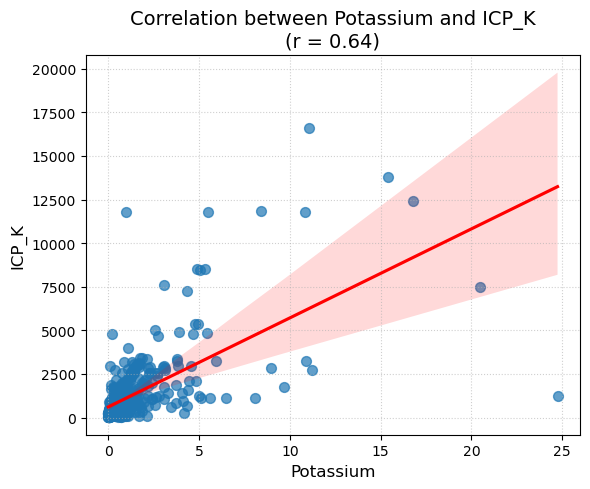

In [18]:
import seaborn as sns
# Ensure relevant columns are present and drop missing values
subset_df = cloud_df_filled[['ICP_K', 'Potassium']].dropna()

# Optional: check correlation coefficient
correlation = subset_df['ICP_K'].corr(subset_df['Potassium'])
print(f"Pearson correlation coefficient: {correlation:.3f}")

# Plot
plt.figure(figsize=(6, 5))
sns.regplot(data=subset_df, x='Potassium', y='ICP_K', scatter_kws={'s': 50, 'alpha': 0.7}, line_kws={'color': 'red'})
plt.title(f'Correlation between Potassium and ICP_K\n(r = {correlation:.2f})', fontsize=14)
plt.xlabel('Potassium', fontsize=12)
plt.ylabel('ICP_K', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


In [19]:
list(cloud_df_filled)

['Time_Stop',
 'Time_Mid',
 'Sodium',
 'Ammonium',
 'DMA',
 'Potassium',
 'Magnesium',
 'Calcium',
 'Glycolate',
 'Acetate',
 'Formate',
 'MSA',
 'Pyruvate',
 'Glyoxylate',
 'Chloride',
 'Nitrite',
 'Bromide',
 'Nitrate',
 'Glutarate',
 'Adipate',
 'Succinate',
 'Maleate',
 'Sulfate',
 'Oxalate',
 'Phthalate',
 'pH',
 'ICP_Li',
 'ICP_Be',
 'ICP_B',
 'ICP_Na',
 'ICP_Mg',
 'ICP_Al',
 'ICP_S',
 'ICP_Cl',
 'ICP_K',
 'ICP_Ca',
 'ICP_Ti',
 'ICP_V',
 'ICP_Cr',
 'ICP_Mn',
 'ICP_Fe',
 'ICP_Co',
 'ICP_Ni',
 'ICP_Cu',
 'ICP_Zn',
 'ICP_Ge',
 'ICP_As',
 'ICP_Br',
 'ICP_Rb',
 'ICP_Sr',
 'ICP_Y',
 'ICP_Zr',
 'ICP_Nb',
 'ICP_Mo',
 'ICP_Ru',
 'ICP_Rh',
 'ICP_Pd',
 'ICP_Ag',
 'ICP_Cd',
 'ICP_Sn',
 'ICP_Sb',
 'ICP_Te',
 'ICP_I',
 'ICP_Cs',
 'ICP_Ba',
 'ICP_Ce',
 'ICP_Hf',
 'ICP_Ta',
 'ICP_W',
 'ICP_Re',
 'ICP_Os',
 'ICP_Ir',
 'ICP_Pt',
 'ICP_Au',
 'ICP_Hg',
 'ICP_Tl',
 'ICP_Pb',
 'ICP_Th',
 'ICP_U']

In [20]:
# List of columns to keep
columns_to_keep = [
    'Sodium', 'Ammonium', 'Magnesium', 'Calcium', 'MSA', 'Potassium',
    'Chloride', 'Nitrate', 'Sulfate', 'Oxalate', 'Phthalate',
    'ICP_Al', 'ICP_Ti', 'ICP_V', 'ICP_Cr', 'ICP_Mn', 'ICP_Fe',
    'ICP_Co', 'ICP_Cu', 'ICP_Zn', 'ICP_As', 'ICP_Rb',
    'ICP_Sr', 'ICP_Y', 'ICP_Zr', 'ICP_Nb', 'ICP_Mo', 'ICP_Cd',
    'ICP_Sn', 'ICP_Cs', 'ICP_Ba', 'ICP_Pb'
]

# Filter the DataFrame
cloud_df_filled = cloud_df_filled[columns_to_keep]
cloud_df_filled

,Sodium,Ammonium,Magnesium,Calcium,MSA,Potassium,Chloride,Nitrate,Sulfate,Oxalate,...,ICP_Sr,ICP_Y,ICP_Zr,ICP_Nb,ICP_Mo,ICP_Cd,ICP_Sn,ICP_Cs,ICP_Ba,ICP_Pb
Time_Start,,,,,,,,,,,,,,,,,,,,,
2020-02-14 17:50:00,17.5200,2.1870,1.984000,1.5490,0.009897,0.38700,28.4800,10.6300,7.3410,0.04861,...,3.906127,0.012639,0.015499,0.003919,0.338235,1.944610,0.260310,0.007507,1.332444,0.418466
2020-02-14 18:00:00,63.8800,2.9100,7.494000,2.5670,0.006454,1.25600,108.2000,17.6600,19.4900,0.30400,...,17.550000,0.039000,0.089000,0.003000,0.381000,43.710000,0.588000,0.012000,9.319000,5.056000
2020-02-14 18:18:20,38.6900,2.0060,4.666000,2.0080,0.003012,0.76380,66.0400,12.3000,12.5500,0.46000,...,17.424540,0.039247,0.089468,0.003000,0.381767,43.422128,0.582162,0.011948,9.331495,5.026186
2020-02-14 19:03:20,117.1000,6.1360,13.950000,4.7100,0.003568,2.31200,198.1000,35.6600,37.2100,0.32080,...,17.116593,0.039853,0.090617,0.003000,0.383650,42.715532,0.567832,0.011820,9.362165,4.953005
2020-02-15 17:30:00,26.5500,1.3130,3.086000,1.3050,0.020220,0.44390,41.7500,17.2800,8.8350,0.13620,...,7.901000,0.058000,0.125000,0.003000,0.440000,21.570000,0.139000,0.008000,10.280000,2.763000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-06-14 14:53:20,0.2471,0.3009,0.009537,0.1405,0.117500,0.41650,0.3108,0.1632,0.2714,0.01781,...,0.378400,0.010370,0.004145,0.031150,0.101200,0.336000,0.065330,0.004240,0.740500,0.008360
2022-06-14 14:56:40,0.4658,0.3328,0.009370,0.1505,0.117500,0.33480,0.5639,0.2217,0.4363,0.01744,...,0.702500,0.017770,0.008417,0.024350,0.101200,0.132100,0.036120,0.004004,1.269000,0.009406
2022-06-14 15:01:40,0.5488,0.3810,0.026150,0.2459,0.117500,0.28600,0.7081,0.2991,0.6490,0.02263,...,0.938000,0.013330,0.010550,0.020960,0.213400,0.250000,0.072640,0.002002,1.730000,0.015160


In [21]:
cloud_df_filled['nss_Sulfate'] = cloud_df_filled['Sulfate'] - (0.2516 * cloud_df_filled['Sodium'])
cloud_df_filled

,Sodium,Ammonium,Magnesium,Calcium,MSA,Potassium,Chloride,Nitrate,Sulfate,Oxalate,...,ICP_Y,ICP_Zr,ICP_Nb,ICP_Mo,ICP_Cd,ICP_Sn,ICP_Cs,ICP_Ba,ICP_Pb,nss_Sulfate
Time_Start,,,,,,,,,,,,,,,,,,,,,
2020-02-14 17:50:00,17.5200,2.1870,1.984000,1.5490,0.009897,0.38700,28.4800,10.6300,7.3410,0.04861,...,0.012639,0.015499,0.003919,0.338235,1.944610,0.260310,0.007507,1.332444,0.418466,2.932968
2020-02-14 18:00:00,63.8800,2.9100,7.494000,2.5670,0.006454,1.25600,108.2000,17.6600,19.4900,0.30400,...,0.039000,0.089000,0.003000,0.381000,43.710000,0.588000,0.012000,9.319000,5.056000,3.417792
2020-02-14 18:18:20,38.6900,2.0060,4.666000,2.0080,0.003012,0.76380,66.0400,12.3000,12.5500,0.46000,...,0.039247,0.089468,0.003000,0.381767,43.422128,0.582162,0.011948,9.331495,5.026186,2.815596
2020-02-14 19:03:20,117.1000,6.1360,13.950000,4.7100,0.003568,2.31200,198.1000,35.6600,37.2100,0.32080,...,0.039853,0.090617,0.003000,0.383650,42.715532,0.567832,0.011820,9.362165,4.953005,7.747640
2020-02-15 17:30:00,26.5500,1.3130,3.086000,1.3050,0.020220,0.44390,41.7500,17.2800,8.8350,0.13620,...,0.058000,0.125000,0.003000,0.440000,21.570000,0.139000,0.008000,10.280000,2.763000,2.155020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-06-14 14:53:20,0.2471,0.3009,0.009537,0.1405,0.117500,0.41650,0.3108,0.1632,0.2714,0.01781,...,0.010370,0.004145,0.031150,0.101200,0.336000,0.065330,0.004240,0.740500,0.008360,0.209230
2022-06-14 14:56:40,0.4658,0.3328,0.009370,0.1505,0.117500,0.33480,0.5639,0.2217,0.4363,0.01744,...,0.017770,0.008417,0.024350,0.101200,0.132100,0.036120,0.004004,1.269000,0.009406,0.319105
2022-06-14 15:01:40,0.5488,0.3810,0.026150,0.2459,0.117500,0.28600,0.7081,0.2991,0.6490,0.02263,...,0.013330,0.010550,0.020960,0.213400,0.250000,0.072640,0.002002,1.730000,0.015160,0.510922


In [22]:
#cloud_df_filled = cloud_df_filled.drop(columns=['Sulfate'])
cloud_df_filled

,Sodium,Ammonium,Magnesium,Calcium,MSA,Potassium,Chloride,Nitrate,Sulfate,Oxalate,...,ICP_Y,ICP_Zr,ICP_Nb,ICP_Mo,ICP_Cd,ICP_Sn,ICP_Cs,ICP_Ba,ICP_Pb,nss_Sulfate
Time_Start,,,,,,,,,,,,,,,,,,,,,
2020-02-14 17:50:00,17.5200,2.1870,1.984000,1.5490,0.009897,0.38700,28.4800,10.6300,7.3410,0.04861,...,0.012639,0.015499,0.003919,0.338235,1.944610,0.260310,0.007507,1.332444,0.418466,2.932968
2020-02-14 18:00:00,63.8800,2.9100,7.494000,2.5670,0.006454,1.25600,108.2000,17.6600,19.4900,0.30400,...,0.039000,0.089000,0.003000,0.381000,43.710000,0.588000,0.012000,9.319000,5.056000,3.417792
2020-02-14 18:18:20,38.6900,2.0060,4.666000,2.0080,0.003012,0.76380,66.0400,12.3000,12.5500,0.46000,...,0.039247,0.089468,0.003000,0.381767,43.422128,0.582162,0.011948,9.331495,5.026186,2.815596
2020-02-14 19:03:20,117.1000,6.1360,13.950000,4.7100,0.003568,2.31200,198.1000,35.6600,37.2100,0.32080,...,0.039853,0.090617,0.003000,0.383650,42.715532,0.567832,0.011820,9.362165,4.953005,7.747640
2020-02-15 17:30:00,26.5500,1.3130,3.086000,1.3050,0.020220,0.44390,41.7500,17.2800,8.8350,0.13620,...,0.058000,0.125000,0.003000,0.440000,21.570000,0.139000,0.008000,10.280000,2.763000,2.155020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-06-14 14:53:20,0.2471,0.3009,0.009537,0.1405,0.117500,0.41650,0.3108,0.1632,0.2714,0.01781,...,0.010370,0.004145,0.031150,0.101200,0.336000,0.065330,0.004240,0.740500,0.008360,0.209230
2022-06-14 14:56:40,0.4658,0.3328,0.009370,0.1505,0.117500,0.33480,0.5639,0.2217,0.4363,0.01744,...,0.017770,0.008417,0.024350,0.101200,0.132100,0.036120,0.004004,1.269000,0.009406,0.319105
2022-06-14 15:01:40,0.5488,0.3810,0.026150,0.2459,0.117500,0.28600,0.7081,0.2991,0.6490,0.02263,...,0.013330,0.010550,0.020960,0.213400,0.250000,0.072640,0.002002,1.730000,0.015160,0.510922


In [23]:
cloud_df_filled.index

DatetimeIndex(['2020-02-14 17:50:00', '2020-02-14 18:00:00',
               '2020-02-14 18:18:20', '2020-02-14 19:03:20',
               '2020-02-15 17:30:00', '2020-02-15 17:36:40',
               '2020-02-15 17:40:35', '2020-02-15 18:03:20',
               '2020-02-15 18:12:10', '2020-02-15 18:53:20',
               ...
               '2022-06-14 14:37:20', '2022-06-14 14:41:10',
               '2022-06-14 14:44:20', '2022-06-14 14:47:20',
               '2022-06-14 14:49:40', '2022-06-14 14:53:20',
               '2022-06-14 14:56:40', '2022-06-14 15:01:40',
               '2022-06-14 15:08:20', '2022-06-14 15:50:50'],
              dtype='datetime64[ns]', name='Time_Start', length=535, freq=None)

In [24]:
# Convert to datetime if not already
cloud_df_filled = cloud_df_filled.reset_index()
cloud_df_filled['Time_Start'] = pd.to_datetime(cloud_df_filled['Time_Start'], errors='coerce')

# Define winter months and years of interest
winter_months = [12, 1, 2, 3, 4]
valid_years = [2020, 2021, 2022]

# Extract winter data in one step
winter_data = cloud_df_filled[
    (cloud_df_filled['Time_Start'].dt.year.isin(valid_years)) &
    (cloud_df_filled['Time_Start'].dt.month.isin(winter_months))
]
winter_data

,Time_Start,Sodium,Ammonium,Magnesium,Calcium,MSA,Potassium,Chloride,Nitrate,Sulfate,...,ICP_Y,ICP_Zr,ICP_Nb,ICP_Mo,ICP_Cd,ICP_Sn,ICP_Cs,ICP_Ba,ICP_Pb,nss_Sulfate
0,2020-02-14 17:50:00,17.520,2.1870,1.9840,1.5490,0.009897,0.38700,28.480,10.6300,7.341,...,0.012639,0.015499,0.003919,0.338235,1.944610,0.260310,0.007507,1.332444,0.418466,2.932968
1,2020-02-14 18:00:00,63.880,2.9100,7.4940,2.5670,0.006454,1.25600,108.200,17.6600,19.490,...,0.039000,0.089000,0.003000,0.381000,43.710000,0.588000,0.012000,9.319000,5.056000,3.417792
2,2020-02-14 18:18:20,38.690,2.0060,4.6660,2.0080,0.003012,0.76380,66.040,12.3000,12.550,...,0.039247,0.089468,0.003000,0.381767,43.422128,0.582162,0.011948,9.331495,5.026186,2.815596
3,2020-02-14 19:03:20,117.100,6.1360,13.9500,4.7100,0.003568,2.31200,198.100,35.6600,37.210,...,0.039853,0.090617,0.003000,0.383650,42.715532,0.567832,0.011820,9.362165,4.953005,7.747640
4,2020-02-15 17:30:00,26.550,1.3130,3.0860,1.3050,0.020220,0.44390,41.750,17.2800,8.835,...,0.058000,0.125000,0.003000,0.440000,21.570000,0.139000,0.008000,10.280000,2.763000,2.155020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,2022-03-29 19:07:00,5.872,0.1616,0.8117,0.1563,0.004664,0.05852,9.327,0.2643,1.593,...,0.002962,0.010719,0.001696,0.150600,0.606400,0.196800,0.002002,0.146800,0.157400,0.115605
439,2022-03-29 19:28:00,36.360,1.2110,4.9900,1.8910,0.018910,0.69690,60.370,4.0640,12.740,...,0.030820,0.052160,0.001699,0.477938,0.272675,0.190413,0.012518,2.295975,1.501925,3.591824
440,2022-03-29 19:31:00,44.230,1.3830,5.9880,2.2640,0.020946,0.81870,73.650,4.8260,15.190,...,0.034800,0.058080,0.001699,0.524700,0.225000,0.189500,0.014020,2.603000,1.694000,4.061732
441,2022-03-29 19:34:30,18.080,0.5597,2.5550,0.9209,0.023320,0.30460,30.380,1.6220,6.269,...,0.034801,0.058082,0.001699,0.524856,0.225312,0.189543,0.014021,2.603447,1.693901,1.720072


In [25]:
# Convert to datetime if not already
cloud_df_filled['Time_Start'] = pd.to_datetime(cloud_df_filled['Time_Start'], errors='coerce')

# Define winter months and years of interest
winter_months = [5, 6, 7, 8, 9]
valid_years = [2020, 2021, 2022]

# Extract winter data in one step
summer_data = cloud_df_filled[
    (cloud_df_filled['Time_Start'].dt.year.isin(valid_years)) &
    (cloud_df_filled['Time_Start'].dt.month.isin(winter_months))
]
summer_data

,Time_Start,Sodium,Ammonium,Magnesium,Calcium,MSA,Potassium,Chloride,Nitrate,Sulfate,...,ICP_Y,ICP_Zr,ICP_Nb,ICP_Mo,ICP_Cd,ICP_Sn,ICP_Cs,ICP_Ba,ICP_Pb,nss_Sulfate
63,2020-08-13 15:01:40,10.1200,0.1762,1.228000,1.0510,0.044750,0.25700,12.8600,8.0960,5.0750,...,0.059438,0.142383,0.012898,0.940162,7.631926,0.420594,0.013923,8.324008,1.620652,2.528808
64,2020-08-13 15:08:20,40.9500,0.1536,4.726000,3.4780,0.346800,1.03800,59.5000,21.6700,15.5900,...,0.059438,0.142383,0.012898,0.940118,7.632084,0.420604,0.013923,8.324048,1.620681,5.286980
65,2020-08-17 16:37:50,41.8400,0.3974,4.828000,1.8230,0.007315,0.94980,66.7100,9.9640,14.0400,...,0.060000,0.142000,0.013000,0.902000,7.771000,0.430000,0.014000,8.359000,1.646000,3.513056
66,2020-08-17 16:39:10,3.5510,0.1842,0.400900,0.2662,0.002151,0.05095,6.0310,1.2840,1.5350,...,0.010000,0.012000,0.004000,0.167000,1.256000,0.135000,0.014000,1.282000,0.460300,0.641568
67,2020-08-17 16:40:50,4.3230,0.4774,0.413700,0.2167,0.002151,0.06805,7.6300,1.0590,1.7330,...,0.004000,0.004000,0.004000,0.253000,1.188000,0.134984,0.014000,0.758400,0.286300,0.645333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,2022-06-14 14:53:20,0.2471,0.3009,0.009537,0.1405,0.117500,0.41650,0.3108,0.1632,0.2714,...,0.010370,0.004145,0.031150,0.101200,0.336000,0.065330,0.004240,0.740500,0.008360,0.209230
531,2022-06-14 14:56:40,0.4658,0.3328,0.009370,0.1505,0.117500,0.33480,0.5639,0.2217,0.4363,...,0.017770,0.008417,0.024350,0.101200,0.132100,0.036120,0.004004,1.269000,0.009406,0.319105
532,2022-06-14 15:01:40,0.5488,0.3810,0.026150,0.2459,0.117500,0.28600,0.7081,0.2991,0.6490,...,0.013330,0.010550,0.020960,0.213400,0.250000,0.072640,0.002002,1.730000,0.015160,0.510922
533,2022-06-14 15:08:20,1.0730,0.5874,0.128000,0.7109,0.117500,0.03805,1.5660,0.5922,0.9961,...,0.013531,0.012215,0.019807,0.234715,0.307342,0.067688,0.002545,1.992644,0.017146,0.726133


In [26]:
winter_data.reset_index(drop=True, inplace=True)


winter_data

,Time_Start,Sodium,Ammonium,Magnesium,Calcium,MSA,Potassium,Chloride,Nitrate,Sulfate,...,ICP_Y,ICP_Zr,ICP_Nb,ICP_Mo,ICP_Cd,ICP_Sn,ICP_Cs,ICP_Ba,ICP_Pb,nss_Sulfate
0,2020-02-14 17:50:00,17.520,2.1870,1.9840,1.5490,0.009897,0.38700,28.480,10.6300,7.341,...,0.012639,0.015499,0.003919,0.338235,1.944610,0.260310,0.007507,1.332444,0.418466,2.932968
1,2020-02-14 18:00:00,63.880,2.9100,7.4940,2.5670,0.006454,1.25600,108.200,17.6600,19.490,...,0.039000,0.089000,0.003000,0.381000,43.710000,0.588000,0.012000,9.319000,5.056000,3.417792
2,2020-02-14 18:18:20,38.690,2.0060,4.6660,2.0080,0.003012,0.76380,66.040,12.3000,12.550,...,0.039247,0.089468,0.003000,0.381767,43.422128,0.582162,0.011948,9.331495,5.026186,2.815596
3,2020-02-14 19:03:20,117.100,6.1360,13.9500,4.7100,0.003568,2.31200,198.100,35.6600,37.210,...,0.039853,0.090617,0.003000,0.383650,42.715532,0.567832,0.011820,9.362165,4.953005,7.747640
4,2020-02-15 17:30:00,26.550,1.3130,3.0860,1.3050,0.020220,0.44390,41.750,17.2800,8.835,...,0.058000,0.125000,0.003000,0.440000,21.570000,0.139000,0.008000,10.280000,2.763000,2.155020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,2022-03-29 19:07:00,5.872,0.1616,0.8117,0.1563,0.004664,0.05852,9.327,0.2643,1.593,...,0.002962,0.010719,0.001696,0.150600,0.606400,0.196800,0.002002,0.146800,0.157400,0.115605
309,2022-03-29 19:28:00,36.360,1.2110,4.9900,1.8910,0.018910,0.69690,60.370,4.0640,12.740,...,0.030820,0.052160,0.001699,0.477938,0.272675,0.190413,0.012518,2.295975,1.501925,3.591824
310,2022-03-29 19:31:00,44.230,1.3830,5.9880,2.2640,0.020946,0.81870,73.650,4.8260,15.190,...,0.034800,0.058080,0.001699,0.524700,0.225000,0.189500,0.014020,2.603000,1.694000,4.061732
311,2022-03-29 19:34:30,18.080,0.5597,2.5550,0.9209,0.023320,0.30460,30.380,1.6220,6.269,...,0.034801,0.058082,0.001699,0.524856,0.225312,0.189543,0.014021,2.603447,1.693901,1.720072


In [27]:
summer_data.reset_index(drop=True, inplace=True)


summer_data

,Time_Start,Sodium,Ammonium,Magnesium,Calcium,MSA,Potassium,Chloride,Nitrate,Sulfate,...,ICP_Y,ICP_Zr,ICP_Nb,ICP_Mo,ICP_Cd,ICP_Sn,ICP_Cs,ICP_Ba,ICP_Pb,nss_Sulfate
0,2020-08-13 15:01:40,10.1200,0.1762,1.228000,1.0510,0.044750,0.25700,12.8600,8.0960,5.0750,...,0.059438,0.142383,0.012898,0.940162,7.631926,0.420594,0.013923,8.324008,1.620652,2.528808
1,2020-08-13 15:08:20,40.9500,0.1536,4.726000,3.4780,0.346800,1.03800,59.5000,21.6700,15.5900,...,0.059438,0.142383,0.012898,0.940118,7.632084,0.420604,0.013923,8.324048,1.620681,5.286980
2,2020-08-17 16:37:50,41.8400,0.3974,4.828000,1.8230,0.007315,0.94980,66.7100,9.9640,14.0400,...,0.060000,0.142000,0.013000,0.902000,7.771000,0.430000,0.014000,8.359000,1.646000,3.513056
3,2020-08-17 16:39:10,3.5510,0.1842,0.400900,0.2662,0.002151,0.05095,6.0310,1.2840,1.5350,...,0.010000,0.012000,0.004000,0.167000,1.256000,0.135000,0.014000,1.282000,0.460300,0.641568
4,2020-08-17 16:40:50,4.3230,0.4774,0.413700,0.2167,0.002151,0.06805,7.6300,1.0590,1.7330,...,0.004000,0.004000,0.004000,0.253000,1.188000,0.134984,0.014000,0.758400,0.286300,0.645333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,2022-06-14 14:53:20,0.2471,0.3009,0.009537,0.1405,0.117500,0.41650,0.3108,0.1632,0.2714,...,0.010370,0.004145,0.031150,0.101200,0.336000,0.065330,0.004240,0.740500,0.008360,0.209230
218,2022-06-14 14:56:40,0.4658,0.3328,0.009370,0.1505,0.117500,0.33480,0.5639,0.2217,0.4363,...,0.017770,0.008417,0.024350,0.101200,0.132100,0.036120,0.004004,1.269000,0.009406,0.319105
219,2022-06-14 15:01:40,0.5488,0.3810,0.026150,0.2459,0.117500,0.28600,0.7081,0.2991,0.6490,...,0.013330,0.010550,0.020960,0.213400,0.250000,0.072640,0.002002,1.730000,0.015160,0.510922
220,2022-06-14 15:08:20,1.0730,0.5874,0.128000,0.7109,0.117500,0.03805,1.5660,0.5922,0.9961,...,0.013531,0.012215,0.019807,0.234715,0.307342,0.067688,0.002545,1.992644,0.017146,0.726133


In [28]:
# file: nss_fraction_calc.py
'''import pandas as pd

def calculate_nss_fractions(Na_bulk_ugL, K_bulk_ugL, Ca_bulk_ugL):
    """
    Calculates non-sea-salt (nss) fractions of Na⁺, K⁺, and Ca²⁺
    from bulk concentrations in µg/L using sea salt and dust mass ratios.

    Parameters:
        Na_bulk_ugL (float): Bulk concentration of Na⁺ in µg/L
        K_bulk_ugL (float): Bulk concentration of K⁺ in µg/L
        Ca_bulk_ugL (float): Bulk concentration of Ca²⁺ in µg/L

    Returns:
        dict: Dictionary with nss and ss values for Na⁺, K⁺, and Ca²⁺ (in µg/L)
    """
    MW_Na = 22.989
    MW_K = 39.098
    MW_Ca = 40.078

    Na_bulk = Na_bulk_ugL / MW_Na
    K_bulk = K_bulk_ugL / MW_K
    Ca_bulk = Ca_bulk_ugL / MW_Ca

    ratio_Ca_Na_ss = 0.038
    ratio_Ca_Na_dust = 1.78
    ratio_K_Na_ss = 0.036

    denominator = ratio_Ca_Na_ss - ratio_Ca_Na_dust
    numerator = Ca_bulk - Na_bulk * ratio_Ca_Na_dust
    ssNa = numerator / denominator if denominator != 0 else 0
    ssNa = max(ssNa, 0)

    ssK = ssNa * ratio_K_Na_ss
    ssCa = ssNa * ratio_Ca_Na_ss

    nssNa = max(Na_bulk - ssNa, 0)
    nssK = max(K_bulk - ssK, 0)
    nssCa = max(Ca_bulk - ssCa, 0)

    return {
        'ssNa': ssNa * MW_Na,
        'nssNa': nssNa * MW_Na,
        'ssK': ssK * MW_K,
        'nssK': nssK * MW_K,
        'ssCa': ssCa * MW_Ca,
        'nssCa': nssCa * MW_Ca
    }

def apply_nss_to_dataframe(df):
    """
    Apply nss fraction calculation to a DataFrame.
    Assumes columns: 'Sodium', 'Potassium', 'Calcium' in µg/L

    Returns:
        pd.DataFrame: Original DataFrame with added columns for ss/nss values.
    """
    results = df[['Sodium', 'Potassium', 'Calcium']].apply(
        lambda row: calculate_nss_fractions(
            row['Sodium'], row['Potassium'], row['Calcium']
        ), axis=1
    )
    results_df = pd.DataFrame(results.tolist(), index=df.index)
    return pd.concat([df, results_df], axis=1)

# Example usage
enriched_df = apply_nss_to_dataframe(cloud_df_filled)
enriched_df'''


'import pandas as pd\n\ndef calculate_nss_fractions(Na_bulk_ugL, K_bulk_ugL, Ca_bulk_ugL):\n    """\n    Calculates non-sea-salt (nss) fractions of Na⁺, K⁺, and Ca²⁺\n    from bulk concentrations in µg/L using sea salt and dust mass ratios.\n\n    Parameters:\n        Na_bulk_ugL (float): Bulk concentration of Na⁺ in µg/L\n        K_bulk_ugL (float): Bulk concentration of K⁺ in µg/L\n        Ca_bulk_ugL (float): Bulk concentration of Ca²⁺ in µg/L\n\n    Returns:\n        dict: Dictionary with nss and ss values for Na⁺, K⁺, and Ca²⁺ (in µg/L)\n    """\n    MW_Na = 22.989\n    MW_K = 39.098\n    MW_Ca = 40.078\n\n    Na_bulk = Na_bulk_ugL / MW_Na\n    K_bulk = K_bulk_ugL / MW_K\n    Ca_bulk = Ca_bulk_ugL / MW_Ca\n\n    ratio_Ca_Na_ss = 0.038\n    ratio_Ca_Na_dust = 1.78\n    ratio_K_Na_ss = 0.036\n\n    denominator = ratio_Ca_Na_ss - ratio_Ca_Na_dust\n    numerator = Ca_bulk - Na_bulk * ratio_Ca_Na_dust\n    ssNa = numerator / denominator if denominator != 0 else 0\n    ssNa = max(ssNa, 

In [29]:
# Apply abs/round to numeric columns only
'''num_cols = winter_data.select_dtypes(include=[np.number]).columns
winter_data[num_cols] = winter_data[num_cols].abs().round(4)


winter_data.to_csv("C:/Users/taiwoajayi/OneDrive - University of Arizona/WinterCloudwater_Output.csv", index=False,
    date_format="%Y-%m-%d %H:%M:%S")'''

'num_cols = winter_data.select_dtypes(include=[np.number]).columns\nwinter_data[num_cols] = winter_data[num_cols].abs().round(4)\n\n\nwinter_data.to_csv("C:/Users/taiwoajayi/OneDrive - University of Arizona/WinterCloudwater_Output.csv", index=False,\n    date_format="%Y-%m-%d %H:%M:%S")'

In [30]:
'''# --- Step 1: Define LODs for known species (units: ppm / µg/mL) ---
lod_dict = {
    'MSA': 0.015,
    'nss_Sulfate': 0.009,
    'Chloride': 0.018,
    'Nitrate': 0.041,
    'Oxalate': 0.015,
    'Phthalate': 0.016,
    'Sodium': 0.063,
    'ssNa': 0.063,
    'nssNa': 0.063,
    'Ammonium': 0.017,
    'Potassium': 0.094,
    'ssk': 0.094,
    'nssk': 0.094,
    'Magnesium': 0.064,
    'nssCa': 0.115,
    'ssCa': 0.115,
    'Calcium': 0.115
}

# --- Step 2: Uncertainty calculation function ---
def calculate_uncertainty_series(concentration_series, error_fraction, lod):
    """Apply uncertainty formula to a pandas Series."""
    return np.sqrt((error_fraction * concentration_series) ** 2 + lod ** 2)

def generate_uncertainty_df(df, lods, error_fraction=0.20):
    """
    Generate uncertainty DataFrame for all numeric columns in the input DataFrame.
    Skips non-numeric columns like 'Time_Start'.
    """
    uncertainty_df = pd.DataFrame(index=df.index)

    for col in df.columns:
        series = df[col]

        # Skip non-numeric columns
        if not pd.api.types.is_numeric_dtype(series):
            continue

        # Use LOD from dictionary if available, else estimate
        if col in lods:
            lod = lods[col]
        else:
            valid = series.dropna()
            small_vals = valid[valid > 0].nsmallest(10)
            lod = small_vals.mean() if not small_vals.empty else np.nan

        # Compute uncertainty
        uncertainty_df[col] = calculate_uncertainty_series(series, error_fraction, lod)

    return uncertainty_df.abs().round(4)


# Generate uncertainty DataFrame
uncertainty_df = generate_uncertainty_df(enriched_df, lod_dict, error_fraction=0.20)
uncertainty_df'''


'# --- Step 1: Define LODs for known species (units: ppm / µg/mL) ---\nlod_dict = {\n    \'MSA\': 0.015,\n    \'nss_Sulfate\': 0.009,\n    \'Chloride\': 0.018,\n    \'Nitrate\': 0.041,\n    \'Oxalate\': 0.015,\n    \'Phthalate\': 0.016,\n    \'Sodium\': 0.063,\n    \'ssNa\': 0.063,\n    \'nssNa\': 0.063,\n    \'Ammonium\': 0.017,\n    \'Potassium\': 0.094,\n    \'ssk\': 0.094,\n    \'nssk\': 0.094,\n    \'Magnesium\': 0.064,\n    \'nssCa\': 0.115,\n    \'ssCa\': 0.115,\n    \'Calcium\': 0.115\n}\n\n# --- Step 2: Uncertainty calculation function ---\ndef calculate_uncertainty_series(concentration_series, error_fraction, lod):\n    """Apply uncertainty formula to a pandas Series."""\n    return np.sqrt((error_fraction * concentration_series) ** 2 + lod ** 2)\n\ndef generate_uncertainty_df(df, lods, error_fraction=0.20):\n    """\n    Generate uncertainty DataFrame for all numeric columns in the input DataFrame.\n    Skips non-numeric columns like \'Time_Start\'.\n    """\n    uncertainty

In [31]:
'''lod_dict = {
    'MSA': 0.015,
    'nss_Sulfate': 0.009,
    'Chloride': 0.018,
    'Nitrate': 0.041,
    'Oxalate': 0.015,
    'Phthalate': 0.016,
    'Sodium': 0.063,
    'ssNa': 0.063,
    'nssNa': 0.063,
    'Ammonium': 0.017,
    'Potassium': 0.094,
    'ssk': 0.094,
    'nssk': 0.094,
    'Magnesium': 0.064,
    'nssCa': 0.115,
    'ssCa': 0.115,
    'Calcium': 0.115
}

def calculate_uncertainty_series(concentration_series, error_fraction, lod):
    """Apply uncertainty formula to a pandas Series."""
    return np.sqrt((error_fraction * concentration_series) ** 2 + lod ** 2)

def generate_uncertainty_df(df, lods, error_fraction=0.20):
    """
    Generate uncertainty DataFrame for all numeric columns in the input DataFrame.
    Preserve Time_Start but do not apply abs/round to it.
    """
    uncertainty_df = pd.DataFrame(index=df.index)

    # Preserve Time_Start (unchanged)
    if 'Time_Start' in df.columns:
        uncertainty_df['Time_Start'] = df['Time_Start']

    for col in df.columns:
        series = df[col]

        # Only process numeric columns
        if not pd.api.types.is_numeric_dtype(series):
            continue

        # LOD: use dict value if available, else estimate from small positives
        if col in lods:
            lod = lods[col]
        else:
            valid = series.dropna()
            small_vals = valid[valid > 0].nsmallest(10)
            lod = small_vals.mean() if not small_vals.empty else np.nan

        # Compute uncertainty
        uncertainty_df[col] = np.sqrt((error_fraction * series) ** 2 + lod ** 2)

    # Post-process ONLY numeric cols
    num_cols = uncertainty_df.select_dtypes(include=['number']).columns
    uncertainty_df[num_cols] = uncertainty_df[num_cols].abs().round(4)

    # Optional: put Time_Start first
    cols = ['Time_Start'] + [c for c in uncertainty_df.columns if c != 'Time_Start']
    return uncertainty_df[cols]


# Generate uncertainty DataFrame
uncertainty_df = generate_uncertainty_df(winter_data, lod_dict, error_fraction=0.20)
uncertainty_df'''



'lod_dict = {\n    \'MSA\': 0.015,\n    \'nss_Sulfate\': 0.009,\n    \'Chloride\': 0.018,\n    \'Nitrate\': 0.041,\n    \'Oxalate\': 0.015,\n    \'Phthalate\': 0.016,\n    \'Sodium\': 0.063,\n    \'ssNa\': 0.063,\n    \'nssNa\': 0.063,\n    \'Ammonium\': 0.017,\n    \'Potassium\': 0.094,\n    \'ssk\': 0.094,\n    \'nssk\': 0.094,\n    \'Magnesium\': 0.064,\n    \'nssCa\': 0.115,\n    \'ssCa\': 0.115,\n    \'Calcium\': 0.115\n}\n\ndef calculate_uncertainty_series(concentration_series, error_fraction, lod):\n    """Apply uncertainty formula to a pandas Series."""\n    return np.sqrt((error_fraction * concentration_series) ** 2 + lod ** 2)\n\ndef generate_uncertainty_df(df, lods, error_fraction=0.20):\n    """\n    Generate uncertainty DataFrame for all numeric columns in the input DataFrame.\n    Preserve Time_Start but do not apply abs/round to it.\n    """\n    uncertainty_df = pd.DataFrame(index=df.index)\n\n    # Preserve Time_Start (unchanged)\n    if \'Time_Start\' in df.columns:\n

In [32]:
'''uncertainty_df.to_csv("C:/Users/taiwoajayi/OneDrive - University of Arizona/winter_Uncertainty_Output.csv", index=False)'''

'uncertainty_df.to_csv("C:/Users/taiwoajayi/OneDrive - University of Arizona/winter_Uncertainty_Output.csv", index=False)'

In [33]:
# Provided LODs (ppm)
'''lod_dict = {
    'MSA': 0.015,
    'nss_Sulfate': 0.009,
    'Chloride': 0.018,
    'Nitrate': 0.041,
    'Oxalate': 0.015,
    'Phthalate': 0.016,
    'Sodium': 0.063,
    'ssNa': 0.063,
    'nssNa': 0.063,
    'Ammonium': 0.017,
    'Potassium': 0.094,
    'ssk': 0.094,
    'nssk': 0.094,
    'Magnesium': 0.064,
    'nssCa': 0.115,
    'ssCa': 0.115,
    'Calcium': 0.115
}

# Initialize empty DataFrame for uncertainties
uncertainty_df = pd.DataFrame(index=enriched_df.index)

# Calculate uncertainties column by column
for col in enriched_df.columns:
    # Use provided LOD or estimate from 10 smallest non-zero values
    if col in lod_dict:
        lod = lod_dict[col]
    else:
        valid_vals = enriched_df[col].dropna()
        small_vals = valid_vals[valid_vals > 0].nsmallest(10)
        lod = small_vals.mean() if not small_vals.empty else np.nan

    # Calculate uncertainty
    uncertainty_df[col] = 0.05 * enriched_df[col] + lod


# Round all values to 4 decimal places
uncertainty_df_rounded = uncertainty_df.round(4)

# Make all values absolute (i.e., remove negative sign)
uncertainty_df_rounded = uncertainty_df_rounded.abs()

# Save to CSV
uncertainty_df_rounded.to_csv("C:/Users/taiwoajayi/OneDrive - University of Arizona/Uncertainty1_Output.csv", index=False)'''


'lod_dict = {\n    \'MSA\': 0.015,\n    \'nss_Sulfate\': 0.009,\n    \'Chloride\': 0.018,\n    \'Nitrate\': 0.041,\n    \'Oxalate\': 0.015,\n    \'Phthalate\': 0.016,\n    \'Sodium\': 0.063,\n    \'ssNa\': 0.063,\n    \'nssNa\': 0.063,\n    \'Ammonium\': 0.017,\n    \'Potassium\': 0.094,\n    \'ssk\': 0.094,\n    \'nssk\': 0.094,\n    \'Magnesium\': 0.064,\n    \'nssCa\': 0.115,\n    \'ssCa\': 0.115,\n    \'Calcium\': 0.115\n}\n\n# Initialize empty DataFrame for uncertainties\nuncertainty_df = pd.DataFrame(index=enriched_df.index)\n\n# Calculate uncertainties column by column\nfor col in enriched_df.columns:\n    # Use provided LOD or estimate from 10 smallest non-zero values\n    if col in lod_dict:\n        lod = lod_dict[col]\n    else:\n        valid_vals = enriched_df[col].dropna()\n        small_vals = valid_vals[valid_vals > 0].nsmallest(10)\n        lod = small_vals.mean() if not small_vals.empty else np.nan\n\n    # Calculate uncertainty\n    uncertainty_df[col] = 0.05 * enric

In [34]:
CVV = fill_remaining_nans_with_geo_mean(CV_df_interp)

CVV.reset_index(inplace=True)
CVV

,Time_Start,Time_Stop,Time_Mid,Duration_CVI_secs,Org_frac_CVI,SO4_frac_CVI,NO3_frac_CVI,NH4_frac_CVI,Chl_frac_CVI,mz42_ORGfrac_CVI,...,Chl_Ave_IsoK_STP,mz42_Ave_IsoK_STP,mz43_Ave_IsoK_STP,mz44_Ave_IsoK_STP,mz55_Ave_IsoK_STP,mz57_Ave_IsoK_STP,mz58_Ave_IsoK_STP,mz60_Ave_IsoK_STP,mz79_Ave_IsoK_STP,mz91_Ave_IsoK_STP
0,2020-02-14 17:26:44,2020-02-14 17:28:19,2020-02-14 17:27:31,95.000000,0.489000,0.000000,0.019000,0.492,0.000000,0.045,...,0.022571,0.040669,0.073462,0.114862,0.039035,0.023168,0.014322,0.014278,0.01521,0.013435
1,2020-02-14 17:32:34,2020-02-14 17:34:29,2020-02-14 17:33:31,116.000000,0.751000,0.000000,0.177000,0.000,0.072000,0.000,...,0.022571,0.040669,0.073462,0.114862,0.039035,0.023168,0.014322,0.014278,0.01521,0.013435
2,2020-02-14 17:50:52,2020-02-14 17:54:52,2020-02-14 17:52:52,240.000000,0.667000,0.059000,0.275000,0.000,0.000000,0.020,...,0.022571,0.040669,0.073462,0.114862,0.039035,0.023168,0.014322,0.014278,0.01521,0.013435
3,2020-02-15 17:11:27,2020-02-15 17:13:44,2020-02-15 17:12:36,137.000000,0.308000,0.376000,0.079000,0.224,0.013000,0.108,...,0.022571,0.040669,0.073462,0.114862,0.039035,0.023168,0.014322,0.014278,0.01521,0.013435
4,2020-02-15 17:19:27,2020-02-15 17:20:23,2020-02-15 17:19:55,56.000000,0.333000,0.440000,0.014000,0.166,0.048000,0.000,...,0.022571,0.040669,0.073462,0.114862,0.039035,0.023168,0.014322,0.014278,0.01521,0.013435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3084,2022-06-13 20:13:58,2022-06-13 20:14:28,2022-06-13 20:14:13,174.555919,0.740668,0.252628,0.004630,0.000,0.002074,0.000,...,0.001000,0.006000,0.052000,-0.010000,0.044000,0.033000,0.005000,-0.015000,0.00800,0.003000
3085,2022-06-13 20:14:28,2022-06-13 20:14:58,2022-06-13 20:14:43,174.576935,0.740767,0.252519,0.004627,0.000,0.002087,0.000,...,-0.004000,0.035000,0.048000,-0.086000,0.014000,0.010000,-0.004000,0.011000,0.00800,-0.005000
3086,2022-06-13 20:14:58,2022-06-13 20:15:28,2022-06-13 20:15:13,174.597951,0.740865,0.252411,0.004625,0.000,0.002099,0.000,...,-0.044000,0.008000,0.063000,-0.038000,0.007000,0.043000,0.011000,-0.000000,0.01900,0.015000
3087,2022-06-13 20:15:28,2022-06-13 20:15:59,2022-06-13 20:15:44,174.618967,0.740964,0.252302,0.004623,0.000,0.002111,0.000,...,-0.009000,-0.012000,0.029000,0.005000,0.005000,0.013000,0.012000,0.002000,0.01100,0.012000


In [35]:
list(CVV)

['Time_Start',
 'Time_Stop',
 'Time_Mid',
 'Duration_CVI_secs',
 'Org_frac_CVI',
 'SO4_frac_CVI',
 'NO3_frac_CVI',
 'NH4_frac_CVI',
 'Chl_frac_CVI',
 'mz42_ORGfrac_CVI',
 'mz43_ORGfrac_CVI',
 'mz44_ORGfrac_CVI',
 'mz55_ORGfrac_CVI',
 'mz57_ORGfrac_CVI',
 'mz58_ORGfrac_CVI',
 'mz60_ORGfrac_CVI',
 'mz79_ORGfrac_CVI',
 'mz91_ORGfrac_CVI',
 'Org_Ave_IsoK_STP',
 'SO4_Ave_IsoK_STP',
 'NO3_Ave_IsoK_STP',
 'NH4_Ave_IsoK_STP',
 'Chl_Ave_IsoK_STP',
 'mz42_Ave_IsoK_STP',
 'mz43_Ave_IsoK_STP',
 'mz44_Ave_IsoK_STP',
 'mz55_Ave_IsoK_STP',
 'mz57_Ave_IsoK_STP',
 'mz58_Ave_IsoK_STP',
 'mz60_Ave_IsoK_STP',
 'mz79_Ave_IsoK_STP',
 'mz91_Ave_IsoK_STP']

In [36]:
'''def match_and_fill_Leg_to_CVI_interp_interp(Leg, CVI_interp, columns_to_add):
    """
    Matches `Time_Start` from `Leg` to `CVI_interp_interp`, forward-filling only until the next available timestamp.
    """
    Leg["Time_Start"] = pd.to_datetime(Leg["Time_Start"])
    CVI_interp["Time_Start"] = pd.to_datetime(CVI_interp["Time_Start"])

    Leg.sort_values("Time_Start", inplace=True)
    CVI_interp.sort_values("Time_Start", inplace=True)

    # ✅ Remove duplicate timestamps from Leg to allow reindexing
    Leg = Leg.drop_duplicates(subset="Time_Start", keep="first")

    Leg = Leg.set_index("Time_Start")
    CVI_interp = CVI_interp.set_index("Time_Start")

    CVI_interp[columns_to_add] = Leg[columns_to_add].reindex(CVI_interp.index, method="ffill")

    CVI_interp.reset_index(inplace=True)
    return CVI_interp

# Example usage:
columns_to_add = ['Julian_Day',	'LegIndex']  # Replace with actual column names

CVI_interp_filled = match_and_fill_Leg_to_CVI_interp_interp(Leg, CVI_interp, columns_to_add)

# ✅ Check if Time_Start has NaT
print(f"Number of NaT values in `Time_Start`: {CVI_interp_filled['Time_Start'].isna().sum()}")'''


'def match_and_fill_Leg_to_CVI_interp_interp(Leg, CVI_interp, columns_to_add):\n    """\n    Matches `Time_Start` from `Leg` to `CVI_interp_interp`, forward-filling only until the next available timestamp.\n    """\n    Leg["Time_Start"] = pd.to_datetime(Leg["Time_Start"])\n    CVI_interp["Time_Start"] = pd.to_datetime(CVI_interp["Time_Start"])\n\n    Leg.sort_values("Time_Start", inplace=True)\n    CVI_interp.sort_values("Time_Start", inplace=True)\n\n    # ✅ Remove duplicate timestamps from Leg to allow reindexing\n    Leg = Leg.drop_duplicates(subset="Time_Start", keep="first")\n\n    Leg = Leg.set_index("Time_Start")\n    CVI_interp = CVI_interp.set_index("Time_Start")\n\n    CVI_interp[columns_to_add] = Leg[columns_to_add].reindex(CVI_interp.index, method="ffill")\n\n    CVI_interp.reset_index(inplace=True)\n    return CVI_interp\n\n# Example usage:\ncolumns_to_add = [\'Julian_Day\',\t\'LegIndex\']  # Replace with actual column names\n\nCVI_interp_filled = match_and_fill_Leg_to_CV

In [37]:
def merge_leg_and_cvv_to_cvi(CVI_interp, Leg, CVV, leg_columns):
    """
    Forward-fills Leg and selected CVV columns into CVI_interp using Time_Start alignment.
    """
    # Convert to datetime
    for df in (CVI_interp, Leg, CVV):
        df["Time_Start"] = pd.to_datetime(df["Time_Start"])

    # Sort and deduplicate
    CVI_interp = CVI_interp.sort_values("Time_Start").drop_duplicates(subset="Time_Start").set_index("Time_Start")
    Leg = Leg.sort_values("Time_Start").drop_duplicates(subset="Time_Start").set_index("Time_Start")
    CVV = CVV.sort_values("Time_Start").drop_duplicates(subset="Time_Start").set_index("Time_Start")

    # Forward fill Leg columns
    CVI_interp[leg_columns] = Leg[leg_columns].reindex(CVI_interp.index, method="ffill")

    # Forward fill selected CVV columns
    selected_cvv_cols = ['SO4_frac_CVI', 'NO3_frac_CVI']
    CVI_interp[selected_cvv_cols] = CVV[selected_cvv_cols].reindex(CVI_interp.index, method="ffill")

    return CVI_interp.reset_index()

# Example usage
leg_columns = ['Julian_Day', 'LegIndex']
CVI_interp_filled = merge_leg_and_cvv_to_cvi(CVI_interp, Leg, CVV, leg_columns)
CVI_interp_filled

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,N_FCDP_VOIGT,LWC_FCDP_VOIGT,Org_Ave_IsoK_STP_ZIEMBA,SO4_Ave_IsoK_STP_ZIEMBA,NO3_Ave_IsoK_STP_ZIEMBA,...,mz57_Ave_IsoK_STP,mz58_Ave_IsoK_STP,mz60_Ave_IsoK_STP,mz79_Ave_IsoK_STP,mz91_Ave_IsoK_STP,sLAS_AmmSO4_ZIEMBA,Julian_Day,LegIndex,SO4_frac_CVI,NO3_frac_CVI
0,2020-02-14 17:03:00,2020-02-14 17:04:00,37.115218,-76.232082,1276.4800,NaN,NaN,1.09202,1.38951,0.43107,...,NaN,NaN,NaN,NaN,NaN,NaN,45,1001110000,NaN,NaN
1,2020-02-14 17:04:00,2020-02-14 17:05:00,37.112182,-76.141177,1526.7600,0.0,0.0,0.73831,1.46784,0.26144,...,NaN,NaN,NaN,NaN,NaN,NaN,45,1001110000,NaN,NaN
2,2020-02-14 17:05:00,2020-02-14 17:06:00,37.097419,-76.051184,1717.0600,0.0,0.0,0.33716,1.01410,0.16795,...,NaN,NaN,NaN,NaN,NaN,NaN,45,1001110000,NaN,NaN
3,2020-02-14 17:06:00,2020-02-14 17:07:00,37.081749,-75.958916,1715.1900,0.0,0.0,0.46504,1.09867,0.25761,...,NaN,NaN,NaN,NaN,NaN,NaN,45,1001110001,NaN,NaN
4,2020-02-14 17:07:00,2020-02-14 17:08:00,37.066479,-75.866394,1712.1700,0.0,0.0,0.59889,1.21982,0.28276,...,NaN,NaN,NaN,NaN,NaN,NaN,45,1001110001,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34315,2022-06-18 15:19:00,2022-06-18 15:20:00,36.893916,-76.031113,764.6068,99494.5,0.0,5.98583,1.59123,0.37663,...,NaN,NaN,NaN,NaN,NaN,170.229,22169,6179100001,0.25,0.019
34316,2022-06-18 15:20:00,2022-06-18 15:21:00,36.887349,-76.107074,555.9031,99494.5,0.0,7.48878,1.44361,0.40135,...,NaN,NaN,NaN,NaN,NaN,170.229,22169,6179100000,0.25,0.019
34317,2022-06-18 15:21:00,2022-06-18 15:22:00,36.861363,-76.165456,396.4723,99494.5,0.0,8.58461,1.35666,0.42955,...,NaN,NaN,NaN,NaN,NaN,170.229,22169,6179100000,0.25,0.019
34318,2022-06-18 15:22:00,2022-06-18 15:23:00,36.859759,-76.209318,200.3306,99494.5,0.0,9.08533,1.29203,0.43807,...,NaN,NaN,NaN,NaN,NaN,170.229,22169,6179100000,0.25,0.019


In [38]:
CVI_interp_filled['N_FCDP_VOIGT'].unique()

array([     nan,     0.  ,  8104.79, ..., 92631.7 , 92630.4 , 99494.5 ])

In [39]:
CVI_interp_filled['LWC_FCDP_VOIGT'] = CVI_interp_filled['LWC_FCDP_VOIGT'] * 1000

CVI_interp_filled['LWC_FCDP_VOIGT'].unique()


array([      nan, 0.000e+00, 2.036e-06, ..., 3.843e-06, 1.137e-06,
       6.045e-06])

In [40]:
CVI_interp_filled['N_FCDP_VOIGT'] = CVI_interp_filled['N_FCDP_VOIGT'] / 1e6


In [41]:
CVI_interp_filled['LWC_FCDP_VOIGT'].unique()

array([      nan, 0.000e+00, 2.036e-06, ..., 3.843e-06, 1.137e-06,
       6.045e-06])

In [42]:
CVI_interp_filled['NO3_frac_CVI'].unique()

array([           nan, 1.90000000e-02, 1.77000000e-01, 2.75000000e-01,
       7.90000000e-02, 1.40000000e-02, 1.93000000e-01, 1.09000000e-01,
       0.00000000e+00, 5.10000000e-02, 6.40000000e-02, 1.11000000e-01,
       1.10000000e-02, 8.70000000e-02, 1.21000000e-01, 6.20000000e-02,
       3.90000000e-02, 8.20000000e-02, 1.54000000e-01, 7.40000000e-02,
       1.04000000e-01, 1.59000000e-01, 5.40000000e-02, 4.40000000e-02,
       7.10000000e-02, 1.18000000e-01, 2.90000000e-02, 2.10000000e-02,
       1.37000000e-01, 1.46000000e-01, 1.03000000e-01, 1.30000000e-02,
       4.30000000e-02, 2.40000000e-02, 3.70000000e-02, 3.50000000e-02,
       1.52000000e-01, 8.10000000e-02, 2.60000000e-02, 3.80000000e-02,
       8.50000000e-02, 3.20000000e-02, 5.50000000e-02, 1.33000000e-01,
       2.39000000e-01, 7.80000000e-02, 1.73000000e-01, 8.30000000e-02,
       6.80000000e-02, 4.00000000e-02, 1.70000000e-01, 3.30000000e-02,
       4.60000000e-02, 3.10000000e-02, 4.10000000e-02, 1.70000000e-02,
      

In [43]:
# Extract leg type from LegIndex
CVI_interp_filled['leg_type'] = CVI_interp_filled['LegIndex'] % 100

In [44]:
CVI_interp_filled

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,N_FCDP_VOIGT,LWC_FCDP_VOIGT,Org_Ave_IsoK_STP_ZIEMBA,SO4_Ave_IsoK_STP_ZIEMBA,NO3_Ave_IsoK_STP_ZIEMBA,...,mz58_Ave_IsoK_STP,mz60_Ave_IsoK_STP,mz79_Ave_IsoK_STP,mz91_Ave_IsoK_STP,sLAS_AmmSO4_ZIEMBA,Julian_Day,LegIndex,SO4_frac_CVI,NO3_frac_CVI,leg_type
0,2020-02-14 17:03:00,2020-02-14 17:04:00,37.115218,-76.232082,1276.4800,NaN,NaN,1.09202,1.38951,0.43107,...,NaN,NaN,NaN,NaN,NaN,45,1001110000,NaN,NaN,0
1,2020-02-14 17:04:00,2020-02-14 17:05:00,37.112182,-76.141177,1526.7600,0.000000,0.0,0.73831,1.46784,0.26144,...,NaN,NaN,NaN,NaN,NaN,45,1001110000,NaN,NaN,0
2,2020-02-14 17:05:00,2020-02-14 17:06:00,37.097419,-76.051184,1717.0600,0.000000,0.0,0.33716,1.01410,0.16795,...,NaN,NaN,NaN,NaN,NaN,45,1001110000,NaN,NaN,0
3,2020-02-14 17:06:00,2020-02-14 17:07:00,37.081749,-75.958916,1715.1900,0.000000,0.0,0.46504,1.09867,0.25761,...,NaN,NaN,NaN,NaN,NaN,45,1001110001,NaN,NaN,1
4,2020-02-14 17:07:00,2020-02-14 17:08:00,37.066479,-75.866394,1712.1700,0.000000,0.0,0.59889,1.21982,0.28276,...,NaN,NaN,NaN,NaN,NaN,45,1001110001,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34315,2022-06-18 15:19:00,2022-06-18 15:20:00,36.893916,-76.031113,764.6068,0.099494,0.0,5.98583,1.59123,0.37663,...,NaN,NaN,NaN,NaN,170.229,22169,6179100001,0.25,0.019,1
34316,2022-06-18 15:20:00,2022-06-18 15:21:00,36.887349,-76.107074,555.9031,0.099494,0.0,7.48878,1.44361,0.40135,...,NaN,NaN,NaN,NaN,170.229,22169,6179100000,0.25,0.019,0
34317,2022-06-18 15:21:00,2022-06-18 15:22:00,36.861363,-76.165456,396.4723,0.099494,0.0,8.58461,1.35666,0.42955,...,NaN,NaN,NaN,NaN,170.229,22169,6179100000,0.25,0.019,0
34318,2022-06-18 15:22:00,2022-06-18 15:23:00,36.859759,-76.209318,200.3306,0.099494,0.0,9.08533,1.29203,0.43807,...,NaN,NaN,NaN,NaN,170.229,22169,6179100000,0.25,0.019,0


In [45]:
# Define masks
clear_air_mask = (CVI_interp_filled['LWC_FCDP_VOIGT'] < 0.02) & (CVI_interp_filled['N_FCDP_VOIGT'] < 10)
cloud_mask     = (CVI_interp_filled['LWC_FCDP_VOIGT'] > 0.02) & (CVI_interp_filled['N_FCDP_VOIGT'] > 10)

# Apply filtering per leg type
BCB = CVI_interp_filled[(CVI_interp_filled['leg_type'] == 2) & clear_air_mask]
ACB = CVI_interp_filled[(CVI_interp_filled['leg_type'] == 3) & cloud_mask]
BCT = CVI_interp_filled[(CVI_interp_filled['leg_type'] == 4) & cloud_mask]
ACT = CVI_interp_filled[(CVI_interp_filled['leg_type'] == 5) & clear_air_mask]


In [46]:
ACT

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,N_FCDP_VOIGT,LWC_FCDP_VOIGT,Org_Ave_IsoK_STP_ZIEMBA,SO4_Ave_IsoK_STP_ZIEMBA,NO3_Ave_IsoK_STP_ZIEMBA,...,mz58_Ave_IsoK_STP,mz60_Ave_IsoK_STP,mz79_Ave_IsoK_STP,mz91_Ave_IsoK_STP,sLAS_AmmSO4_ZIEMBA,Julian_Day,LegIndex,SO4_frac_CVI,NO3_frac_CVI,leg_type
43,2020-02-14 17:46:00,2020-02-14 17:47:00,37.016172,-72.609529,1623.34,0.001930,1.507000e-07,-0.04570,0.187770,0.172070,...,NaN,NaN,NaN,NaN,NaN,45,1001110105,0.000,0.177,5
44,2020-02-14 17:47:00,2020-02-14 17:48:00,37.086411,-72.583091,1619.61,0.002002,9.797000e-07,-0.03278,0.238150,0.280980,...,NaN,NaN,NaN,NaN,NaN,45,1001110105,0.000,0.177,5
45,2020-02-14 17:48:00,2020-02-14 17:49:00,37.153616,-72.550494,1619.47,0.001522,6.637000e-08,0.23920,0.366750,0.288400,...,NaN,NaN,NaN,NaN,NaN,45,1001110105,0.000,0.177,5
46,2020-02-14 17:49:00,2020-02-14 17:50:00,37.219650,-72.516540,1616.14,0.001545,4.267000e-08,0.30308,0.361760,0.244070,...,NaN,NaN,NaN,NaN,NaN,45,1001110105,0.000,0.177,5
80,2020-02-14 18:23:00,2020-02-14 18:24:00,39.239005,-71.418350,2365.91,0.000497,1.373000e-08,0.22027,0.073133,0.041967,...,NaN,NaN,NaN,NaN,NaN,45,1001110205,0.059,0.275,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34155,2022-06-18 12:39:00,2022-06-18 12:40:00,33.517291,-66.534250,1823.35,0.001471,4.062000e-08,0.39750,0.133400,0.049600,...,NaN,NaN,NaN,NaN,170.229,22169,6179110105,0.000,0.000,5
34156,2022-06-18 12:40:00,2022-06-18 12:41:00,33.556384,-66.598483,1760.86,0.000456,1.258000e-08,0.61647,0.192600,0.031067,...,NaN,NaN,NaN,NaN,170.229,22169,6179110105,0.000,0.000,5
34157,2022-06-18 12:41:00,2022-06-18 12:42:00,33.597967,-66.665314,1455.38,0.014465,1.076000e-06,0.21107,0.393770,0.032667,...,NaN,NaN,NaN,NaN,170.229,22169,6179110105,0.000,0.000,5
34193,2022-06-18 13:17:00,2022-06-18 13:18:00,34.905490,-68.907358,1864.75,0.243033,1.584000e-05,3.54433,2.245170,0.221420,...,NaN,NaN,NaN,NaN,170.229,22169,6179110205,0.303,0.029,5


In [47]:
in_cloud = CVI_interp_filled[(CVI_interp_filled['LWC_FCDP_VOIGT'] > 0.02) & (CVI_interp_filled['N_FCDP_VOIGT'] > 10)]
in_cloud

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,N_FCDP_VOIGT,LWC_FCDP_VOIGT,Org_Ave_IsoK_STP_ZIEMBA,SO4_Ave_IsoK_STP_ZIEMBA,NO3_Ave_IsoK_STP_ZIEMBA,...,mz58_Ave_IsoK_STP,mz60_Ave_IsoK_STP,mz79_Ave_IsoK_STP,mz91_Ave_IsoK_STP,sLAS_AmmSO4_ZIEMBA,Julian_Day,LegIndex,SO4_frac_CVI,NO3_frac_CVI,leg_type
49,2020-02-14 17:52:00,2020-02-14 17:53:00,37.417084,-72.413125,1393.8200,341.112000,0.25560,0.779195,0.947730,0.362740,...,NaN,NaN,NaN,NaN,NaN,45,1001110104,0.059,0.275,4
50,2020-02-14 17:53:00,2020-02-14 17:54:00,37.477911,-72.380153,1391.0900,379.805000,0.20780,0.943098,0.914585,0.386620,...,NaN,NaN,NaN,NaN,NaN,45,1001110104,0.059,0.275,4
58,2020-02-14 18:01:00,2020-02-14 18:02:00,37.943224,-72.131743,1111.3900,151.324000,0.03939,1.145860,0.915150,0.645660,...,NaN,NaN,NaN,NaN,NaN,45,1001110203,0.059,0.275,3
59,2020-02-14 18:02:00,2020-02-14 18:03:00,38.001502,-72.100085,1109.4600,186.999000,0.04749,1.146000,1.005500,0.737500,...,NaN,NaN,NaN,NaN,NaN,45,1001110203,0.059,0.275,3
60,2020-02-14 18:03:00,2020-02-14 18:04:00,38.060149,-72.068491,1096.6800,118.844000,0.02754,1.157800,0.979380,0.805050,...,NaN,NaN,NaN,NaN,NaN,45,1001110203,0.059,0.275,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34200,2022-06-18 13:24:00,2022-06-18 13:25:00,35.161495,-69.359425,1433.1200,98.971207,0.06912,3.525000,1.620000,0.253000,...,NaN,NaN,NaN,NaN,170.229,22169,6179110213,0.130,0.067,13
34211,2022-06-18 13:35:00,2022-06-18 13:36:00,35.567863,-70.000707,469.1752,187.548000,0.03058,1.315430,0.793120,0.003354,...,NaN,NaN,NaN,NaN,170.229,22169,6179110303,0.146,0.003,3
34222,2022-06-18 13:46:00,2022-06-18 13:47:00,35.880402,-70.671103,456.0485,152.115000,0.02607,3.998000,1.461000,0.172000,...,NaN,NaN,NaN,NaN,170.229,22169,6179110306,0.146,0.003,6
34223,2022-06-18 13:47:00,2022-06-18 13:48:00,35.914510,-70.732844,467.0751,233.547000,0.17140,5.102040,1.708040,0.218075,...,NaN,NaN,NaN,NaN,170.229,22169,6179110303,0.258,0.049,3


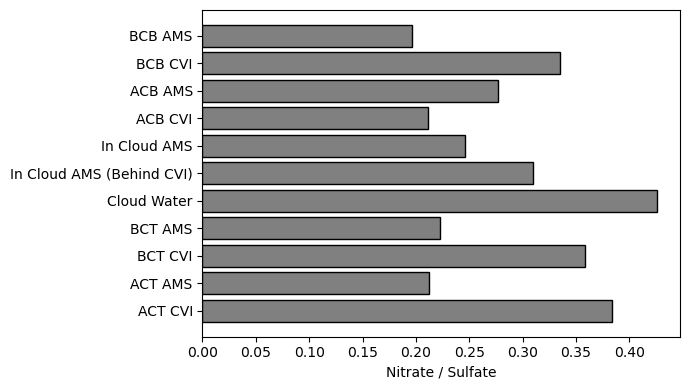

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate Nitrate/Sulfate ratios for each region/type
ratios = {
    'ACT CVI': (ACT['NO3_frac_CVI'].mean() / ACT['SO4_frac_CVI'].mean()),
    'ACT AMS': (ACT['NO3_Ave_IsoK_STP_ZIEMBA'].mean() / ACT['SO4_Ave_IsoK_STP_ZIEMBA'].mean()),
    'BCT CVI': (BCT['NO3_frac_CVI'].mean() / BCT['SO4_frac_CVI'].mean()),
    'BCT AMS': (BCT['NO3_Ave_IsoK_STP_ZIEMBA'].mean() / BCT['SO4_Ave_IsoK_STP_ZIEMBA'].mean()),
    'Cloud Water': (cloud_df_filled['Nitrate'].mean() / cloud_df_filled['Sulfate'].mean()),
    'In Cloud AMS (Behind CVI)': (in_cloud['NO3_frac_CVI'].mean() / in_cloud['SO4_frac_CVI'].mean()),
    'In Cloud AMS': (in_cloud['NO3_Ave_IsoK_STP_ZIEMBA'].mean() / in_cloud['SO4_Ave_IsoK_STP_ZIEMBA'].mean()),
    'ACB CVI': (ACB['NO3_frac_CVI'].mean() / ACB['SO4_frac_CVI'].mean()),
    'ACB AMS': (ACB['NO3_Ave_IsoK_STP_ZIEMBA'].mean() / ACB['SO4_Ave_IsoK_STP_ZIEMBA'].mean()),
    'BCB CVI': (BCB['NO3_frac_CVI'].mean() / BCB['SO4_frac_CVI'].mean()),
    'BCB AMS': (BCB['NO3_Ave_IsoK_STP_ZIEMBA'].mean() / BCB['SO4_Ave_IsoK_STP_ZIEMBA'].mean()),
}

# Create DataFrame for plotting
plot_df = pd.DataFrame({
    'Region': list(ratios.keys()),
    'Nitrate/Sulfate': list(ratios.values())
})

# Plotting
plt.figure(figsize=(7, 4))
plt.barh(plot_df['Region'], plot_df['Nitrate/Sulfate'], color='gray', edgecolor='black')
plt.xlabel('Nitrate / Sulfate')
plt.tight_layout()
plt.show()


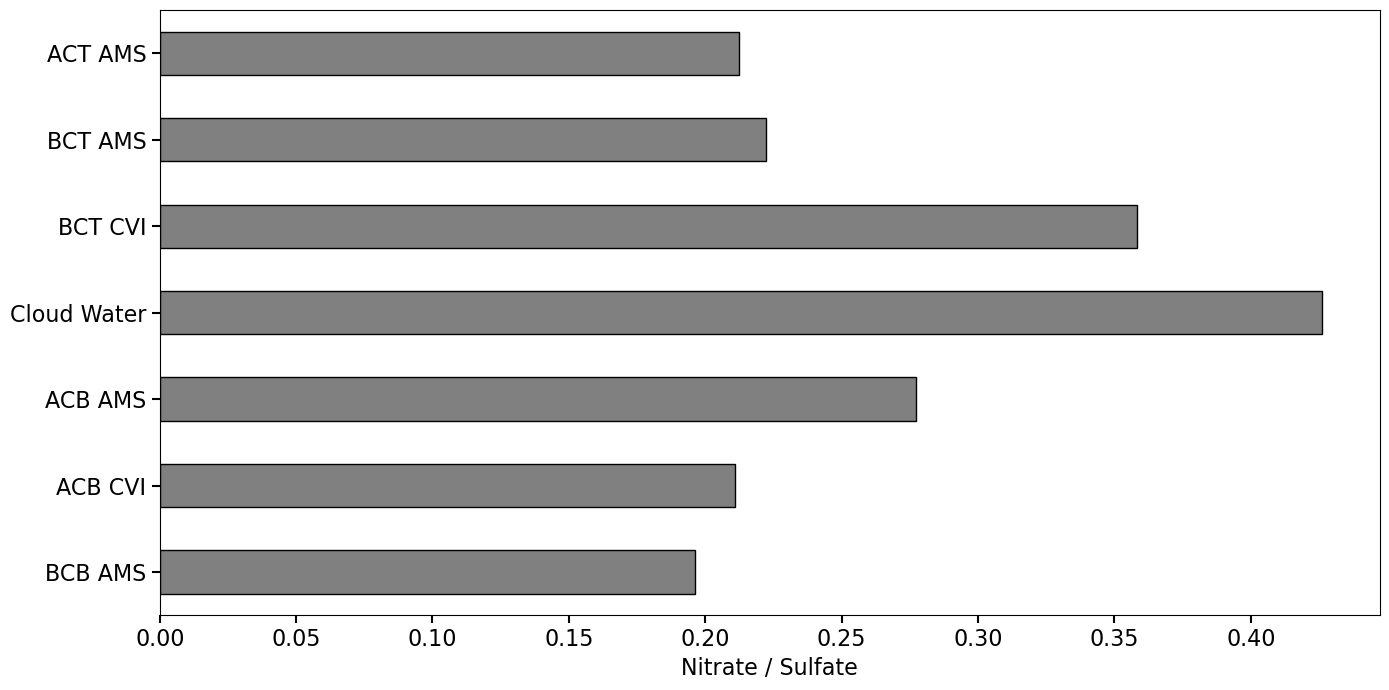

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate Nitrate/Sulfate ratios for each region/type
ratios = {
    #'ACT CVI': (ACT['NO3_frac_CVI'].mean() / ACT['SO4_frac_CVI'].mean()),
    'ACT AMS': (ACT['NO3_Ave_IsoK_STP_ZIEMBA'].mean() / ACT['SO4_Ave_IsoK_STP_ZIEMBA'].mean()),
    'BCT CVI': (BCT['NO3_frac_CVI'].mean() / BCT['SO4_frac_CVI'].mean()),
    'BCT AMS': (BCT['NO3_Ave_IsoK_STP_ZIEMBA'].mean() / BCT['SO4_Ave_IsoK_STP_ZIEMBA'].mean()),
    'Cloud Water': (cloud_df_filled['Nitrate'].mean() / cloud_df_filled['Sulfate'].mean()),
    #'In Cloud AMS (Behind CVI)': (in_cloud['NO3_frac_CVI'].mean() / in_cloud['SO4_frac_CVI'].mean()),
    #'In Cloud AMS': (in_cloud['NO3_Ave_IsoK_STP_ZIEMBA'].mean() / in_cloud['SO4_Ave_IsoK_STP_ZIEMBA'].mean()),
    'ACB CVI': (ACB['NO3_frac_CVI'].mean() / ACB['SO4_frac_CVI'].mean()),
    'ACB AMS': (ACB['NO3_Ave_IsoK_STP_ZIEMBA'].mean() / ACB['SO4_Ave_IsoK_STP_ZIEMBA'].mean()),
    #'BCB CVI': (BCB['NO3_frac_CVI'].mean() / BCB['SO4_frac_CVI'].mean()),
    'BCB AMS': (BCB['NO3_Ave_IsoK_STP_ZIEMBA'].mean() / BCB['SO4_Ave_IsoK_STP_ZIEMBA'].mean()),
}

custom_order = [
    'BCB AMS',
    'ACB CVI', 'ACB AMS',
    'Cloud Water',
    #'In Cloud AMS (Behind CVI)', 'In Cloud AMS',
    'BCT CVI', 'BCT AMS',
    'ACT AMS'
]

# Create ordered Series
plot_series = pd.Series(ratios).reindex(custom_order)

# Plot
plt.figure(figsize=(14, 7))
plot_series.plot(kind='barh', color='gray', edgecolor='black')
plt.tick_params(axis='both', which='major', labelsize=16, length=6, width=1.5)
plt.xlabel('Nitrate / Sulfate', fontsize=16)
plt.tight_layout()
plt.show()